# 16 — Golden + Hotspot-veto + EGM Iso 0.25 Integrated 1-LJ vs 2-LJ Mother Tracking and Kinematics

This notebook is the comprehensive counterpart to notebook `14`. It applies the same golden-JSON, 2018 eta–phi hotspot-veto, EGM-isolation-0.25 production, while restoring the Inclusive, Signal-like (`both_pass`), and Background-like (`both_fail`) comparisons from notebook `11`.

Analysis flow:

1. validate the 18 merged background samples and 12 channels;
2. compare Inclusive, Signal-like, and Background-like LJ-entry yields;
3. study background-process and generator-mother composition;
4. compare 1-LJ and 2-LJ kinematics and selection-dependent shapes;
5. inspect eta–phi occupancy and the 2017/2018 reference veto regions.

### Overflow policy

All 1D yield and kinematic helpers fold underflow and overflow into the first and last visible bins before integration, normalization, or rebinning. The 2D eta–phi diagnostic uses the visible map range directly; its axes already cover the selected objects.


In [1]:
import os
import sys
from collections import defaultdict
from pathlib import Path

import coffea.util
import hist
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

# Compatibility for NumPy-2-created coffea files in the current image.
if "numpy._core.numeric" not in sys.modules:
    sys.modules["numpy._core.numeric"] = np.core.numeric

sidm_path = str(Path.cwd()).split("/sidm")[0]
if sidm_path not in sys.path:
    sys.path.insert(1, sidm_path)

from sidm.tools import utilities

utilities.set_plot_style()
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
%matplotlib inline

In [2]:
cwd = Path.cwd()
if cwd.name == "Mother_Tracking":
    study_dir = cwd
elif (cwd / "studies" / "Mother_Tracking").exists():
    study_dir = cwd / "studies" / "Mother_Tracking"
else:
    raise RuntimeError(f"Cannot locate studies/Mother_Tracking from {cwd}")

INPUT_DIR = study_dir / "1LJvs2LJ_golden_hotspot_iso025_v1_bkg_merged_samples_v1"

SAMPLES = [
    "TTJets",
    "QCD_Pt15To20", "QCD_Pt20To30", "QCD_Pt30To50", "QCD_Pt50To80",
    "QCD_Pt80To120", "QCD_Pt120To170", "QCD_Pt170To300",
    "QCD_Pt300To470", "QCD_Pt470To600", "QCD_Pt600To800",
    "QCD_Pt800To1000", "QCD_Pt1000",
    "DYJetsToLL_M10to50", "DYJetsToLL_M50", "WW", "WZ", "ZZ",
]

# Bottom-to-top order for stacked plots.
BACKGROUND_GROUPS = {
    "Diboson": ["WW", "WZ", "ZZ"],
    "TT": ["TTJets"],
    "DY": [sample for sample in SAMPLES if sample.startswith("DYJets")],
    "QCD": [sample for sample in SAMPLES if sample.startswith("QCD_")],
}
GROUP_COLORS = {
    "Diboson": "#009E73", "TT": "#0072B2",
    "DY": "#E69F00", "QCD": "#6F2DA8",
}

BASE_CHANNELS = {
    "1 mu-LJ": "data_control_region_1muLj",
    "1 egm-LJ": "data_control_region_1egmLj",
    "1 mu-LJ + 1 egm-LJ": "data_control_region_1muLj_1egmLj",
    "2 mu-LJ": "data_control_region_2muLj",
}
SELECTION_SUFFIX = ""
REGION_SUFFIX = {
    "Inclusive": "",
    "Signal-like": "_both_pass",
    "Background-like": "_both_fail",
}
CHANNEL_COLORS = {
    "1 mu-LJ": "#0072B2", "1 egm-LJ": "#E69F00",
    "1 mu-LJ + 1 egm-LJ": "#009E73", "2 mu-LJ": "#CC79A7",
}
REGION_STYLES = {
    "Inclusive": ("black", "-"),
    "Signal-like": ("red", "-"),
    "Background-like": ("blue", "--"),
}
ANCHOR_HISTOGRAM = {
    "1 mu-LJ": "mu_lj_pt",
    "1 egm-LJ": "egm_lj_pt",
    "1 mu-LJ + 1 egm-LJ": "mu_lj_pt",
    "2 mu-LJ": "mu_lj_pt",
}

assert INPUT_DIR.is_dir(), f"Missing input directory: {INPUT_DIR}"
missing_files = [sample for sample in SAMPLES if not (INPUT_DIR / f"{sample}.coffea").is_file()]
assert not missing_files, f"Missing coffea files: {missing_files}"
print(f"Input: {INPUT_DIR}")
print(f"Samples: {len(SAMPLES)}")

Input: /home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/studies/Mother_Tracking/1LJvs2LJ_golden_hotspot_iso025_v1_bkg_merged_samples_v1
Samples: 18


## Load and validate the 12-channel outputs

In [3]:
out = {}
validation_rows = []
expected_channels = {
    f"{base}{suffix}{SELECTION_SUFFIX}"
    for base in BASE_CHANNELS.values()
    for suffix in REGION_SUFFIX.values()
}
required_hists = {
    "mu_lj_pt", "mu_lj_eta", "mu_lj_phi", "mu_lj_mass_small", "mu_lj_iso",
    "mu_lj_dRSpread", "mu_lj_muonN", "mu_lj_pfMu_n", "mu_lj_dsaMu_n",
    "egm_lj_pt", "egm_lj_eta", "egm_lj_phi", "egm_lj_mass_small", "egm_lj_iso",
    "egm_lj_dRSpread", "egm_lj_electronN", "egm_lj_photonN",
    "fs_gen_mother_id", "fs_e_gen_mother_id", "fs_mu_gen_mother_id", "fs_pho_gen_mother_id",
}

for sample in SAMPLES:
    loaded = coffea.util.load(INPUT_DIR / f"{sample}.coffea")
    sample_out = loaded.get("out", loaded)[sample]
    out[sample] = sample_out
    hists = sample_out["hists"]
    missing_hists = sorted(required_hists - set(hists))
    channel_axis = hists["mu_lj_pt"].axes["channel"]
    available_channels = set(channel_axis)
    missing_channels = sorted(expected_channels - available_channels)
    metadata = sample_out.get("metadata", {})
    validation_rows.append({
        "sample": sample,
        "n_events_processed": metadata.get("n_evts", np.nan),
        "n_histograms": len(hists),
        "n_channels": len(channel_axis),
        "missing_histograms": ", ".join(missing_hists),
        "missing_channels": ", ".join(missing_channels),
        "status": "ok" if not missing_hists and not missing_channels else "incomplete",
    })

validation = pd.DataFrame(validation_rows).set_index("sample")
display(validation)
assert validation["status"].eq("ok").all(), "At least one sample is incomplete"

,n_events_processed,n_histograms,n_channels,missing_histograms,missing_channels,status
sample,,,,,,
TTJets,2396626,32,12,,,ok
QCD_Pt15To20,853,32,12,,,ok
QCD_Pt20To30,22954,32,12,,,ok
QCD_Pt30To50,107897,32,12,,,ok
QCD_Pt50To80,212290,32,12,,,ok
QCD_Pt80To120,641772,32,12,,,ok
QCD_Pt120To170,605553,32,12,,,ok
QCD_Pt170To300,3795715,32,12,,,ok
QCD_Pt300To470,6999747,32,12,,,ok


## Histogram helpers and overflow handling

The checks below make the overflow convention explicit and reusable. `folded_1d` is used for both yields and plotted shapes.

In [4]:
def channel_name(channel_label, region):
    return f"{BASE_CHANNELS[channel_label]}{REGION_SUFFIX[region]}{SELECTION_SUFFIX}"


def sum_histogram(samples, channel, histogram_name):
    total = None
    used = []
    for sample in samples:
        histogram = out[sample]["hists"][histogram_name][{"channel": channel}]
        total = histogram.copy() if total is None else total + histogram
        used.append(sample)
    if total is None:
        raise RuntimeError(f"No histogram found: {histogram_name}, {channel}")
    return total, used


def folded_1d(histogram):
    values = np.asarray(histogram.values(flow=True), dtype=float)
    variances = histogram.variances(flow=True)
    variances = np.abs(values) if variances is None else np.asarray(variances, dtype=float)
    folded_values = values[1:-1].copy()
    folded_variances = variances[1:-1].copy()
    folded_values[0] += values[0]
    folded_values[-1] += values[-1]
    folded_variances[0] += variances[0]
    folded_variances[-1] += variances[-1]
    return np.asarray(histogram.axes[0].edges), folded_values, folded_variances


def histogram_yield(histogram):
    _, values, variances = folded_1d(histogram)
    return float(values.sum()), float(variances.sum())


def normalized_shape(histogram, rebin=1):
    edges, values, variances = folded_1d(histogram)
    if rebin > 1:
        usable = (len(values) // rebin) * rebin
        values = values[:usable].reshape(-1, rebin).sum(axis=1)
        variances = variances[:usable].reshape(-1, rebin).sum(axis=1)
        edges = edges[:usable + 1:rebin]
        if len(edges) != len(values) + 1:
            edges = np.append(edges, histogram.axes[0].edges[usable])
    total = values.sum()
    if total <= 0:
        return edges, np.zeros_like(values), np.zeros_like(values)
    return edges, values / total, np.sqrt(variances) / total


def ratio_uncertainty(numerator, numerator_error, denominator, denominator_error):
    numerator = np.asarray(numerator, dtype=float)
    numerator_error = np.asarray(numerator_error, dtype=float)
    denominator = np.asarray(denominator, dtype=float)
    denominator_error = np.asarray(denominator_error, dtype=float)
    ratio = np.full(numerator.shape, np.nan)
    error = np.full(numerator.shape, np.nan)
    valid = np.isfinite(numerator) & np.isfinite(denominator) & (denominator > 0)
    ratio[valid] = numerator[valid] / denominator[valid]
    positive = valid & (numerator > 0)
    error[positive] = ratio[positive] * np.sqrt(
        (numerator_error[positive] / numerator[positive]) ** 2
        + (denominator_error[positive] / denominator[positive]) ** 2
    )
    zero = valid & (numerator == 0)
    error[zero] = numerator_error[zero] / denominator[zero]
    return ratio, error

## Inclusive, Signal-like, and Background-like LJ-entry yields

The anchor histogram is `mu_lj_pt` for mu-LJ channels and `egm_lj_pt` for the 1-egm-LJ channel. Since these histograms count LJ entries, this section deliberately does not label them as event yields.

In [5]:
channel_process_yields = {}
channel_process_errors = {}

for channel_label in BASE_CHANNELS:
    rows = []
    error_rows = []
    histogram_name = ANCHOR_HISTOGRAM[channel_label]
    for region in REGION_SUFFIX:
        row = {"region": region}
        error_row = {"region": region}
        channel = channel_name(channel_label, region)
        for group, samples in BACKGROUND_GROUPS.items():
            histogram, _ = sum_histogram(samples, channel, histogram_name)
            value, variance = histogram_yield(histogram)
            row[group] = value
            error_row[group] = np.sqrt(variance)
        rows.append(row)
        error_rows.append(error_row)
    channel_process_yields[channel_label] = pd.DataFrame(rows).set_index("region")
    channel_process_errors[channel_label] = pd.DataFrame(error_rows).set_index("region")
    display(Markdown(f"### {channel_label}: LJ-entry yield"))
    display(channel_process_yields[channel_label].round(5))

### 1 mu-LJ: LJ-entry yield

,Diboson,TT,DY,QCD
region,,,,
Inclusive,494.18217,18466.68665,80344.49454,9.332675e+06
Signal-like,8.63204,108.03061,2374.12432,9.510196e+04
Background-like,85.63786,12793.44291,4166.16563,6.413530e+06


### 1 egm-LJ: LJ-entry yield

,Diboson,TT,DY,QCD
region,,,,
Inclusive,53.76240,3463.52676,4438.15716,33346.19121
Signal-like,14.15158,324.09182,2899.68233,11535.73319
Background-like,5.86409,788.95080,469.24542,12801.71374


### 1 mu-LJ + 1 egm-LJ: LJ-entry yield

,Diboson,TT,DY,QCD
region,,,,
Inclusive,17.76375,2717.13347,974.39201,70971.38554
Signal-like,0.00000,3.27365,0.00000,182.33223
Background-like,0.00000,435.39609,12.99216,25853.56061


### 2 mu-LJ: LJ-entry yield

,Diboson,TT,DY,QCD
region,,,,
Inclusive,7.26139,458.31167,992.09343,49889.46523
Signal-like,0.00000,6.54731,6.49608,0.01543
Background-like,0.41342,229.15584,0.00000,33624.08835


/tmp/ipykernel_2775/1653194889.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show(); plt.close(fig)


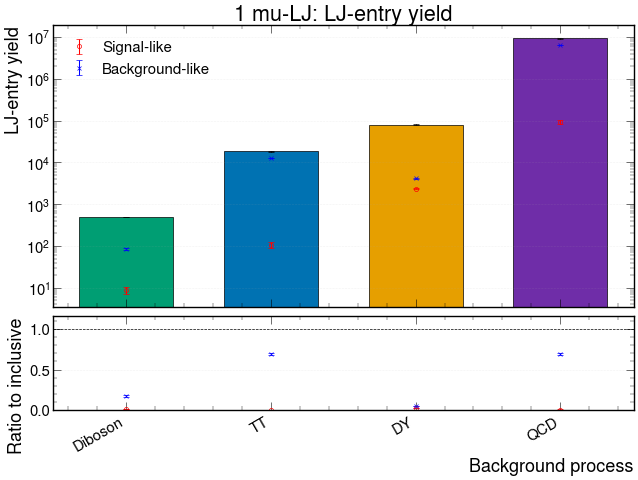

/tmp/ipykernel_2775/1653194889.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show(); plt.close(fig)


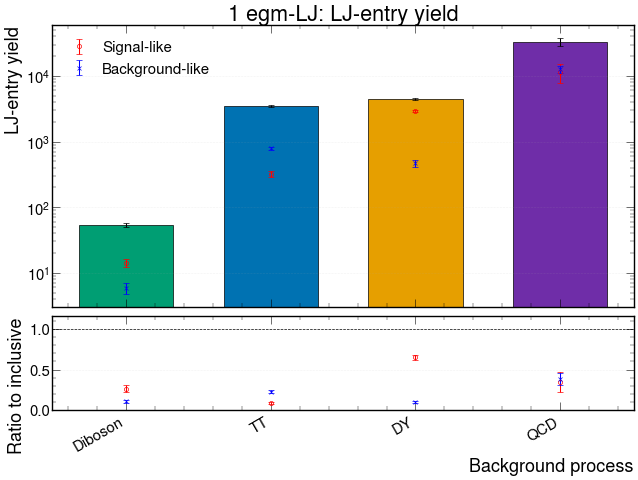

/tmp/ipykernel_2775/1653194889.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show(); plt.close(fig)


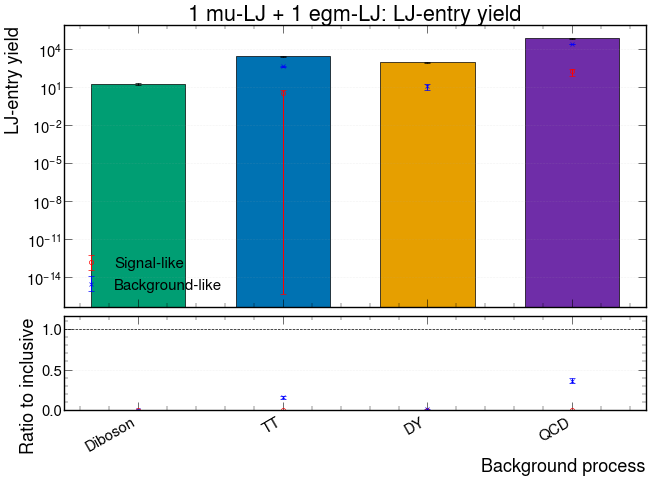

/tmp/ipykernel_2775/1653194889.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show(); plt.close(fig)


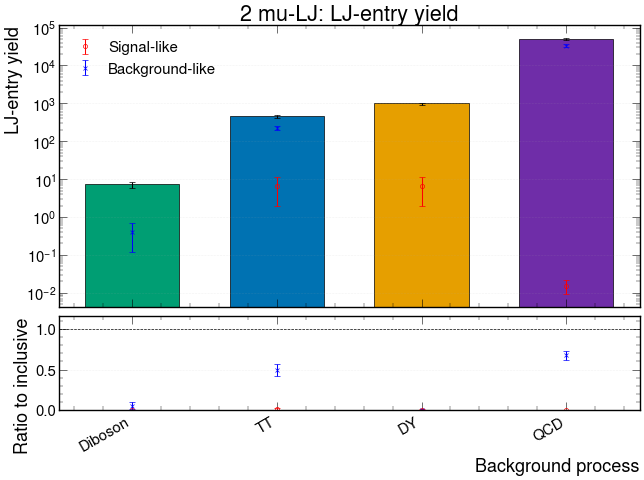

In [6]:
def plot_channel_yield_ratio(channel_label):
    table = channel_process_yields[channel_label]
    errors = channel_process_errors[channel_label]
    processes = list(BACKGROUND_GROUPS)
    x = np.arange(len(processes))
    inclusive = table.loc["Inclusive", processes].to_numpy(float)
    inclusive_error = errors.loc["Inclusive", processes].to_numpy(float)
    signal = table.loc["Signal-like", processes].to_numpy(float)
    signal_error = errors.loc["Signal-like", processes].to_numpy(float)
    background = table.loc["Background-like", processes].to_numpy(float)
    background_error = errors.loc["Background-like", processes].to_numpy(float)
    fig, (ax, rax) = plt.subplots(2, 1, figsize=(15, 10), sharex=True,
                                  gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05})
    colors = [GROUP_COLORS[process] for process in processes]
    ax.bar(x, inclusive, color=colors, edgecolor="black", width=0.65)
    mask = inclusive > 0
    ax.errorbar(x[mask], inclusive[mask], yerr=inclusive_error[mask], fmt="none", ecolor="black", capsize=4)
    for values, errs, marker, color, label in (
        (signal, signal_error, "o", "red", "Signal-like"),
        (background, background_error, "x", "blue", "Background-like"),
    ):
        visible = values > 0
        ax.errorbar(x[visible], values[visible], yerr=errs[visible], marker=marker,
                    markerfacecolor="none" if marker == "o" else color,
                    color=color, ecolor=color, linestyle="none", capsize=4, label=label)
        ratio, ratio_error = ratio_uncertainty(values, errs, inclusive, inclusive_error)
        valid = np.isfinite(ratio)
        rax.errorbar(x[valid], ratio[valid], yerr=ratio_error[valid], marker=marker,
                     markerfacecolor="none" if marker == "o" else color,
                     color=color, ecolor=color, linestyle="none", capsize=4)
    ax.set_yscale("log")
    ax.set(title=f"{channel_label}: LJ-entry yield", ylabel="LJ-entry yield")
    ax.grid(axis="y", linestyle=":", alpha=0.3)
    ax.legend(frameon=False)
    rax.axhline(1, color="black", linestyle="--", linewidth=1)
    rax.set(ylabel="Ratio to inclusive", xlabel="Background process", ylim=(0, 1.15))
    rax.set_xticks(x, processes, rotation=30, ha="right")
    rax.grid(axis="y", linestyle=":", alpha=0.3)
    plt.tight_layout(); plt.show(); plt.close(fig)

for channel_label in BASE_CHANNELS:
    plot_channel_yield_ratio(channel_label)

## Background-process composition across the 12 channels

Only fractions are plotted here. Yield information is already contained in the Inclusive/Signal-like/Background-like panels above.

,Diboson,TT,DY,QCD
channel,,,,
1 mu-LJ — Inclusive,0.01,0.20,0.85,98.95
1 mu-LJ — Signal-like,0.01,0.11,2.43,97.45
1 mu-LJ — Background-like,0.00,0.20,0.06,99.73
1 egm-LJ — Inclusive,0.13,8.39,10.75,80.74
1 egm-LJ — Signal-like,0.10,2.19,19.63,78.08
1 egm-LJ — Background-like,0.04,5.61,3.34,91.01
1 mu-LJ + 1 egm-LJ — Inclusive,0.02,3.64,1.30,95.03
1 mu-LJ + 1 egm-LJ — Signal-like,0.00,1.76,0.00,98.24
1 mu-LJ + 1 egm-LJ — Background-like,0.00,1.66,0.05,98.30


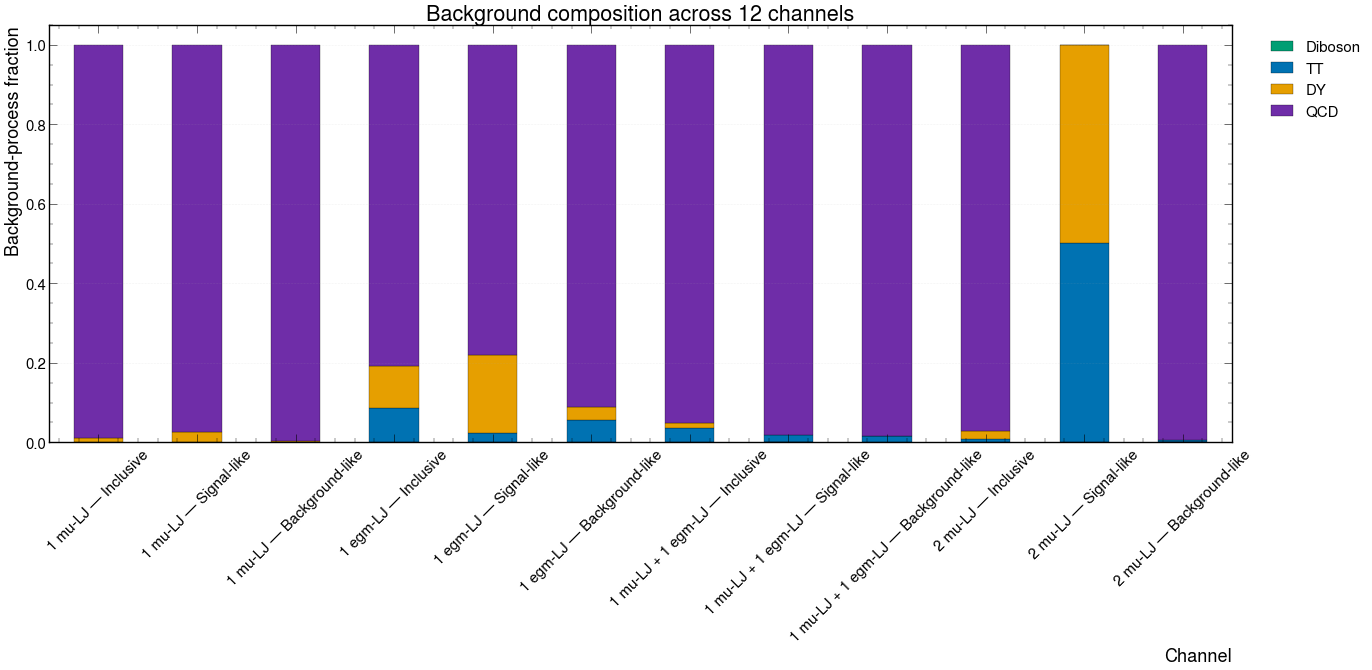

In [7]:
process_fraction_rows = []
for channel_label in BASE_CHANNELS:
    for region in REGION_SUFFIX:
        yields = channel_process_yields[channel_label].loc[region]
        total = yields.sum()
        row = {"channel": f"{channel_label} — {region}"}
        for process in BACKGROUND_GROUPS:
            row[process] = yields[process] / total if total > 0 else 0.0
        process_fraction_rows.append(row)
process_fraction_table = pd.DataFrame(process_fraction_rows).set_index("channel")
display((100 * process_fraction_table).round(2))
ax = process_fraction_table.plot(
    kind="bar", stacked=True, figsize=(28, 14),
    color=[GROUP_COLORS[p] for p in process_fraction_table.columns],
    edgecolor="black", linewidth=0.4,
)
ax.set(xlabel="Channel", ylabel="Background-process fraction", title="Background composition across 12 channels")
ax.tick_params(axis="x", rotation=45)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
ax.grid(axis="y", linestyle=":", alpha=0.3)
plt.tight_layout(); plt.show(); plt.close()

## Generator-mother composition

In [8]:
MOTHER_CATEGORY_ORDER = [
    "Z", "W", "e", "Muon", r"$\pi$", r"$\eta$/$\omega$",
    "B Meson", "D Meson", "Quark/Gluon", r"J/$\Psi$", "Others",
]
MOTHER_COLORS = {
    "Z": "#0072B2", "W": "#E69F00", "e": "#CC79A7", "Muon": "#17BECF",
    r"$\pi$": "#009E73", r"$\eta$/$\omega$": "#56B4E9",
    "B Meson": "#D55E00", "D Meson": "#F0E442",
    "Quark/Gluon": "#6F2DA8", r"J/$\Psi$": "#8C564B", "Others": "#7F7F7F",
}
MOTHER_HISTOGRAMS = {
    "All matched objects": "fs_gen_mother_id",
    "Electron": "fs_e_gen_mother_id",
    "Muon": "fs_mu_gen_mother_id",
    "Photon": "fs_pho_gen_mother_id",
}

def categorize_background_mother(pdgid):
    abs_id = abs(int(pdgid))
    if abs_id == 23: return "Z"
    if abs_id == 24: return "W"
    if abs_id == 11: return "e"
    if abs_id == 13: return "Muon"
    if abs_id in (111, 211): return r"$\pi$"
    if abs_id in (221, 223): return r"$\eta$/$\omega$"
    if abs_id in (511, 521, 531, 541): return "B Meson"
    if abs_id in (411, 421, 423, 431): return "D Meson"
    if abs_id in (1, 2, 3, 4, 5, 6, 9, 21): return "Quark/Gluon"
    if abs_id == 443: return r"J/$\Psi$"
    return "Others"


def categorize_mother_histogram(histogram):
    flow_values = np.asarray(histogram.values(flow=True), dtype=float)
    flow_variances = histogram.variances(flow=True)
    flow_variances = np.abs(flow_values) if flow_variances is None else np.asarray(flow_variances, dtype=float)
    centers = np.asarray(histogram.axes[0].centers, dtype=int)
    yields = defaultdict(float)
    variances = defaultdict(float)
    for pdgid, value, variance in zip(centers, flow_values[1:-1], flow_variances[1:-1]):
        category = categorize_background_mother(pdgid)
        yields[category] += float(value)
        variances[category] += float(variance)
    yields["Others"] += float(flow_values[0] + flow_values[-1])
    variances["Others"] += float(flow_variances[0] + flow_variances[-1])
    return yields, variances


def mother_category_table(samples, channel, histogram_name):
    histogram, _ = sum_histogram(samples, channel, histogram_name)
    yields, variances = categorize_mother_histogram(histogram)
    return (
        pd.Series(yields).reindex(MOTHER_CATEGORY_ORDER, fill_value=0.0),
        np.sqrt(pd.Series(variances).reindex(MOTHER_CATEGORY_ORDER, fill_value=0.0)),
    )

### Common mother order (lowest total yield first)

,mother-object yield
e,5.068972e+03
W,4.012776e+04
Z,6.997429e+04
Muon,1.345303e+05
$\eta$/$\omega$,2.610192e+06
Others,9.582919e+06
J/$\Psi$,1.016658e+07
Quark/Gluon,1.301642e+07
$\pi$,1.639808e+07
B Meson,2.328808e+07


### All matched objects: mother composition (%)

,e,W,Z,Muon,$\eta$/$\omega$,Others,J/$\Psi$,Quark/Gluon,$\pi$,B Meson,D Meson
channel,,,,,,,,,,,
1 mu-LJ — Inclusive,0.00,0.03,0.09,0.14,2.03,10.17,8.43,14.50,15.50,24.07,25.04
1 mu-LJ — Signal-like,0.00,0.02,0.54,0.41,1.20,10.34,3.16,32.61,13.99,18.46,19.28
1 mu-LJ — Background-like,0.00,0.02,0.00,0.05,2.24,10.04,8.18,10.44,16.27,25.93,26.84
1 egm-LJ — Inclusive,1.46,3.11,0.08,3.14,2.53,6.83,0.06,9.87,48.83,17.41,6.69
1 egm-LJ — Signal-like,0.31,0.78,0.10,10.60,1.13,2.09,0.00,20.05,61.93,1.96,1.05
1 egm-LJ — Background-like,0.27,0.65,0.00,0.09,3.18,8.88,0.12,5.70,41.16,29.60,10.34
1 mu-LJ + 1 egm-LJ — Inclusive,0.22,0.58,0.08,0.18,2.85,8.24,5.59,6.94,28.63,24.11,22.58
1 mu-LJ + 1 egm-LJ — Signal-like,0.00,0.33,0.00,0.00,0.76,3.93,14.54,3.45,31.60,24.80,20.59
1 mu-LJ + 1 egm-LJ — Background-like,0.05,0.15,0.00,0.03,2.29,6.60,6.16,6.46,27.51,27.53,23.22


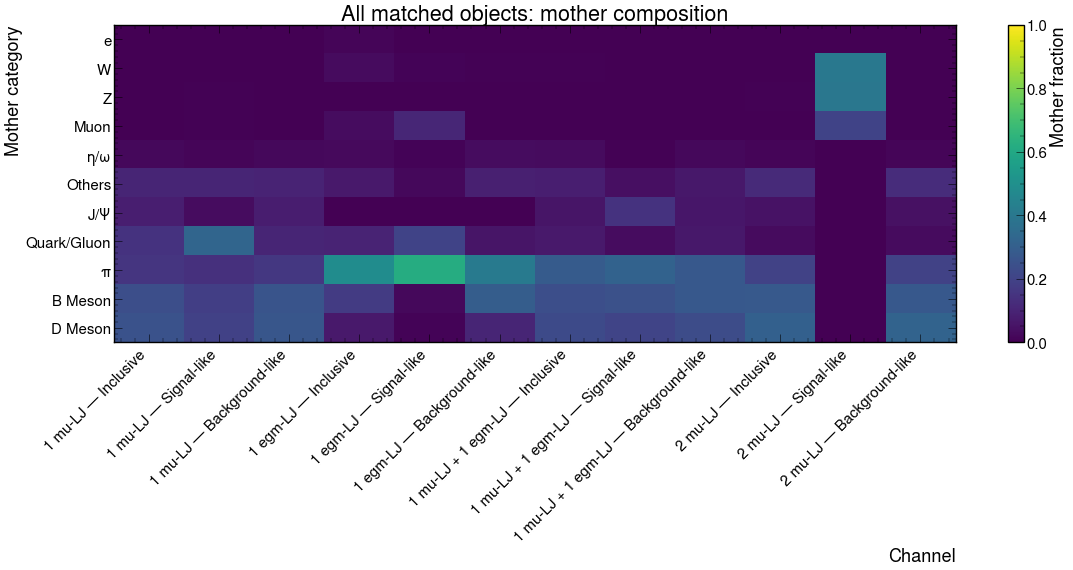

### Electron: mother composition (%)

,e,W,Z,Muon,$\eta$/$\omega$,Others,J/$\Psi$,Quark/Gluon,$\pi$,B Meson,D Meson
channel,,,,,,,,,,,
1 mu-LJ — Inclusive,0.00,0.01,0.00,0.03,1.88,7.57,0.05,46.28,20.36,6.30,17.53
1 mu-LJ — Signal-like,0.00,0.00,0.00,0.11,0.77,10.62,0.00,66.98,8.97,5.98,6.57
1 mu-LJ — Background-like,0.00,0.00,0.00,0.00,1.40,7.10,0.05,45.06,21.23,6.56,18.58
1 egm-LJ — Inclusive,0.05,16.61,0.28,0.23,1.35,2.97,0.32,16.28,7.14,46.88,7.90
1 egm-LJ — Signal-like,0.00,29.69,0.06,0.00,4.21,6.32,0.00,19.37,7.36,26.73,6.26
1 egm-LJ — Background-like,0.00,2.58,0.01,0.14,1.93,2.75,0.48,13.28,9.79,59.49,9.55
1 mu-LJ + 1 egm-LJ — Inclusive,0.03,3.95,0.21,0.08,2.81,5.08,0.73,23.31,13.85,34.98,14.98
1 mu-LJ + 1 egm-LJ — Signal-like,0.00,0.00,0.00,0.00,0.00,0.00,0.00,9.33,0.00,44.94,45.72
1 mu-LJ + 1 egm-LJ — Background-like,0.00,0.62,0.01,0.00,0.85,3.79,0.20,26.97,10.39,40.81,16.34


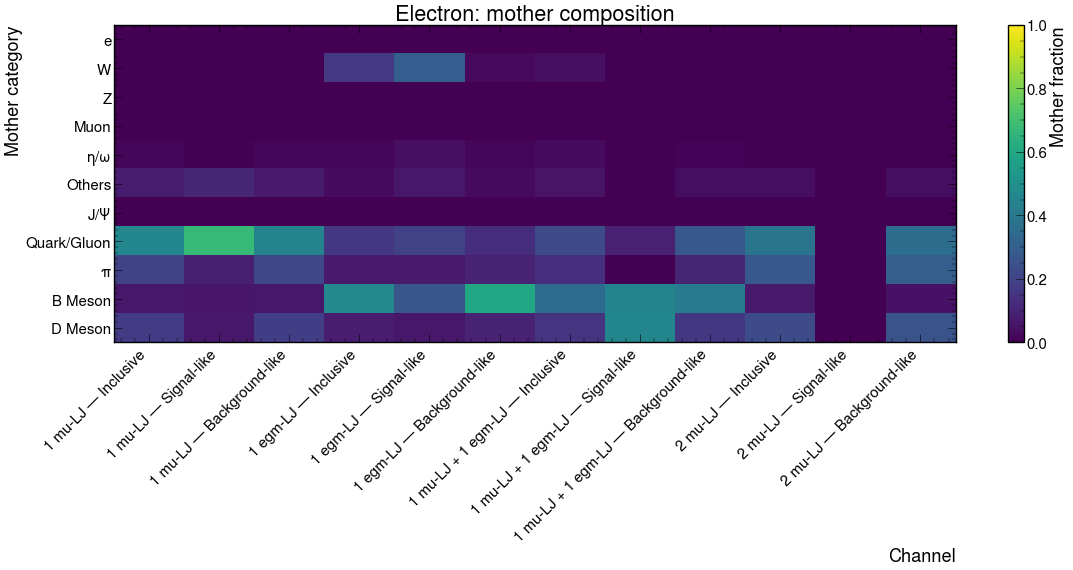

### Muon: mother composition (%)

,e,W,Z,Muon,$\eta$/$\omega$,Others,J/$\Psi$,Quark/Gluon,$\pi$,B Meson,D Meson
channel,,,,,,,,,,,
1 mu-LJ — Inclusive,0.00,0.05,0.17,0.0,2.59,9.62,15.85,15.02,10.75,23.20,22.75
1 mu-LJ — Signal-like,0.00,0.04,1.02,0.0,1.38,9.05,6.00,34.00,12.72,17.51,18.29
1 mu-LJ — Background-like,0.00,0.03,0.01,0.0,2.94,9.69,15.76,9.76,11.27,25.54,24.99
1 egm-LJ — Inclusive,0.00,0.13,0.34,0.0,0.40,26.55,0.00,1.44,53.63,1.78,15.72
1 egm-LJ — Signal-like,0.00,0.49,0.99,0.0,0.00,8.43,0.00,3.54,78.46,3.50,4.59
1 egm-LJ — Background-like,0.00,0.00,0.00,0.0,0.38,30.82,0.00,0.58,44.83,0.77,22.62
1 mu-LJ + 1 egm-LJ — Inclusive,0.02,0.44,0.16,0.0,1.36,9.73,15.03,7.27,15.60,23.91,26.48
1 mu-LJ + 1 egm-LJ — Signal-like,0.00,1.39,0.00,0.0,0.00,3.56,60.29,0.57,3.55,19.96,10.68
1 mu-LJ + 1 egm-LJ — Background-like,0.00,0.16,0.00,0.0,2.15,8.20,17.65,4.45,17.18,23.82,26.38


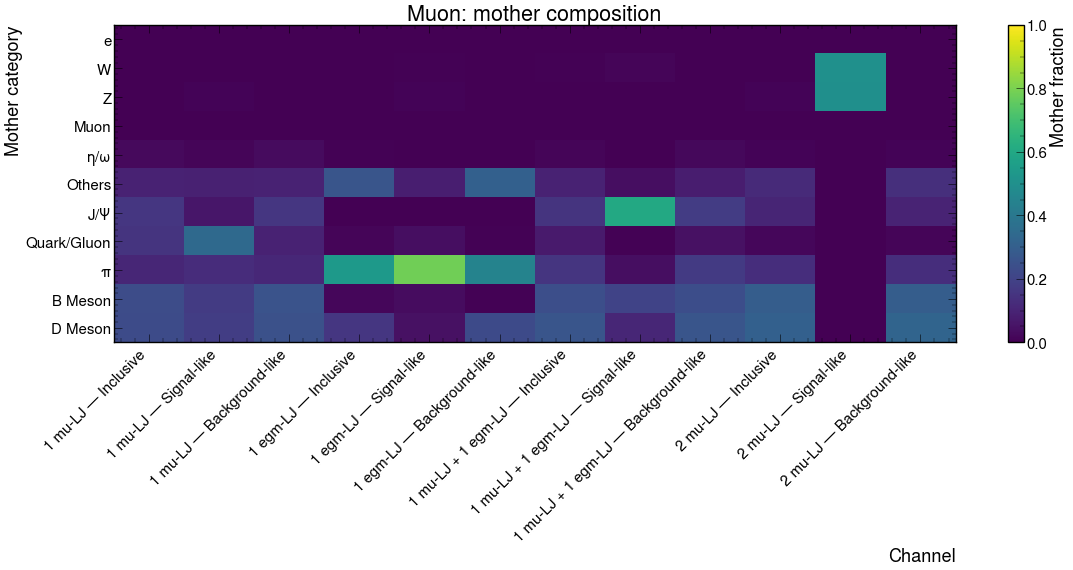

### Photon: mother composition (%)

,e,W,Z,Muon,$\eta$/$\omega$,Others,J/$\Psi$,Quark/Gluon,$\pi$,B Meson,D Meson
channel,,,,,,,,,,,
1 mu-LJ — Inclusive,0.00,0.01,0.0,2.77,11.93,2.86,0.0,6.50,74.98,0.01,0.94
1 mu-LJ — Signal-like,0.00,0.03,0.0,10.26,12.20,3.24,0.0,8.51,65.22,0.00,0.55
1 mu-LJ — Background-like,0.00,0.01,0.0,0.84,12.53,2.91,0.0,2.77,79.89,0.00,1.05
1 egm-LJ — Inclusive,3.34,0.24,0.0,7.15,5.19,0.48,0.0,13.55,70.04,0.00,0.00
1 egm-LJ — Signal-like,0.52,0.31,0.0,17.83,1.79,0.18,0.0,32.58,46.79,0.00,0.00
1 egm-LJ — Background-like,0.93,0.03,0.0,0.18,9.11,0.18,0.0,1.08,88.49,0.00,0.00
1 mu-LJ + 1 egm-LJ — Inclusive,1.10,0.07,0.0,0.91,10.96,0.96,0.0,5.95,79.81,0.00,0.23
1 mu-LJ + 1 egm-LJ — Signal-like,0.00,0.00,0.0,0.00,8.79,0.15,0.0,20.96,70.10,0.00,0.00
1 mu-LJ + 1 egm-LJ — Background-like,0.30,0.02,0.0,0.21,9.15,0.93,0.0,1.44,87.64,0.00,0.32


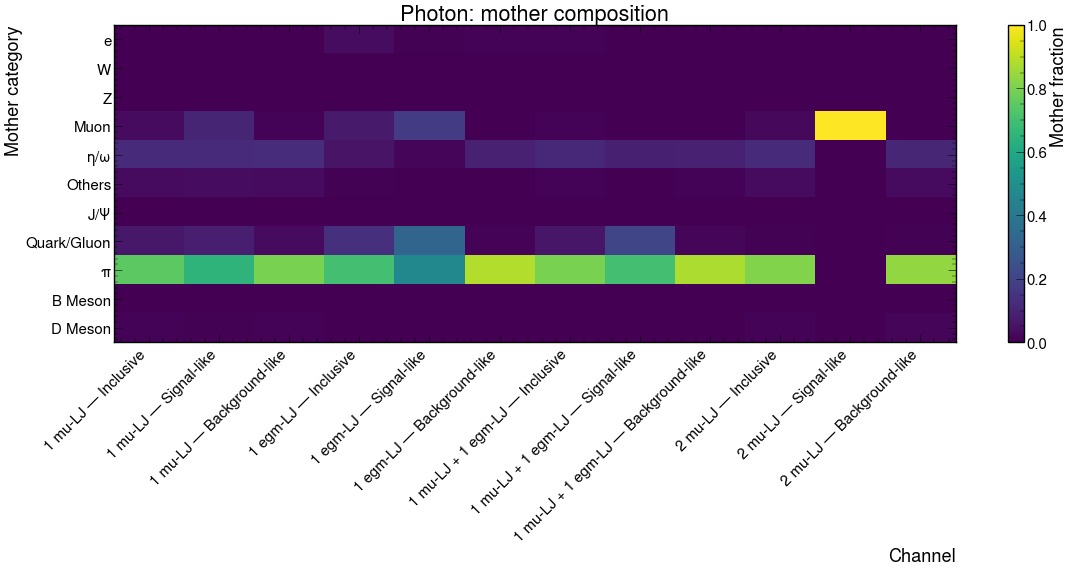

In [9]:
mother_fraction_tables = {}
global_mother_yield = pd.Series(0.0, index=MOTHER_CATEGORY_ORDER)
for object_label, histogram_name in MOTHER_HISTOGRAMS.items():
    rows = []
    for channel_label in BASE_CHANNELS:
        for region in REGION_SUFFIX:
            series, _ = mother_category_table(SAMPLES, channel_name(channel_label, region), histogram_name)
            total = series.sum()
            rows.append({"channel": f"{channel_label} — {region}", **(series / total if total > 0 else series * 0)})
            global_mother_yield = global_mother_yield.add(series, fill_value=0.0)
    mother_fraction_tables[object_label] = pd.DataFrame(rows).set_index("channel").reindex(columns=MOTHER_CATEGORY_ORDER)

MOTHER_STACK_ORDER = global_mother_yield.sort_values(kind="stable").index.tolist()
display(Markdown("### Common mother order (lowest total yield first)"))
display(global_mother_yield.reindex(MOTHER_STACK_ORDER).rename("mother-object yield").to_frame())

for object_label, table in mother_fraction_tables.items():
    table = table.reindex(columns=MOTHER_STACK_ORDER)
    mother_fraction_tables[object_label] = table
    display(Markdown(f"### {object_label}: mother composition (%)"))
    display((100 * table).round(2))
    fig, ax = plt.subplots(figsize=(24, 12))
    image = ax.imshow(table.T.to_numpy(), aspect="auto", vmin=0, vmax=1, cmap="viridis")
    ax.set_xticks(np.arange(len(table.index)), table.index, rotation=45, ha="right")
    ax.set_yticks(np.arange(len(table.columns)), table.columns)
    ax.set(title=f"{object_label}: mother composition", xlabel="Channel", ylabel="Mother category")
    fig.colorbar(image, ax=ax, label="Mother fraction")
    plt.tight_layout(); plt.show(); plt.close(fig)

## Process-resolved mother yield and Signal-like/Background-like ratios

Following notebook `02`, each panel compares Inclusive mother-object yield with Signal-like and Background-like values. The lower panel shows ratios to Inclusive with propagated uncertainties.

/tmp/ipykernel_2775/524050169.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show(); plt.close(fig)


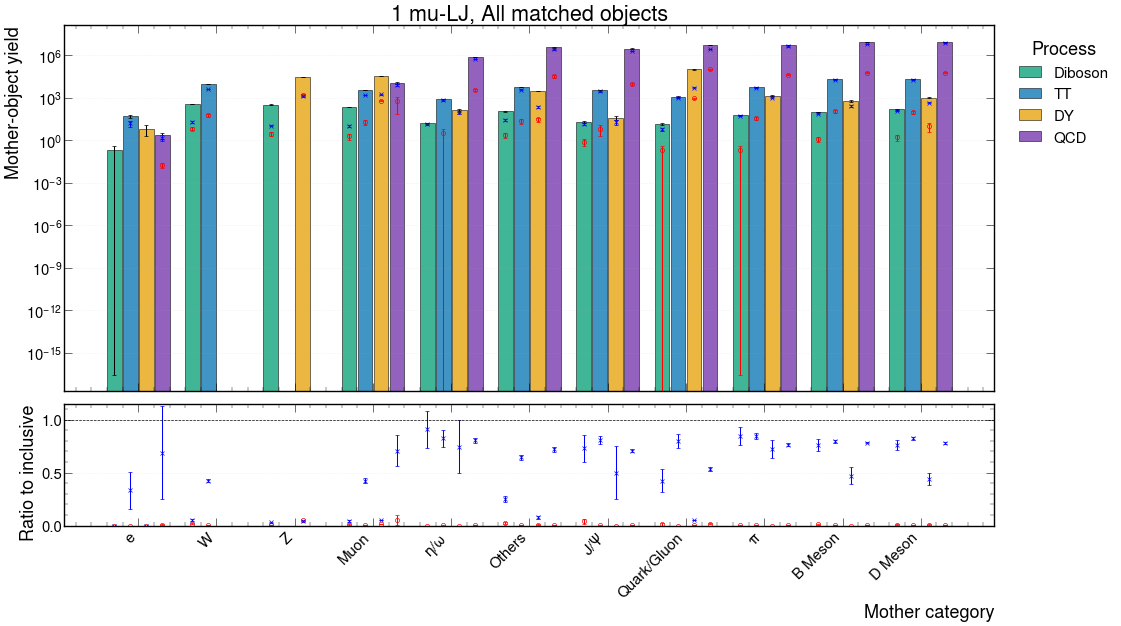

/tmp/ipykernel_2775/524050169.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show(); plt.close(fig)


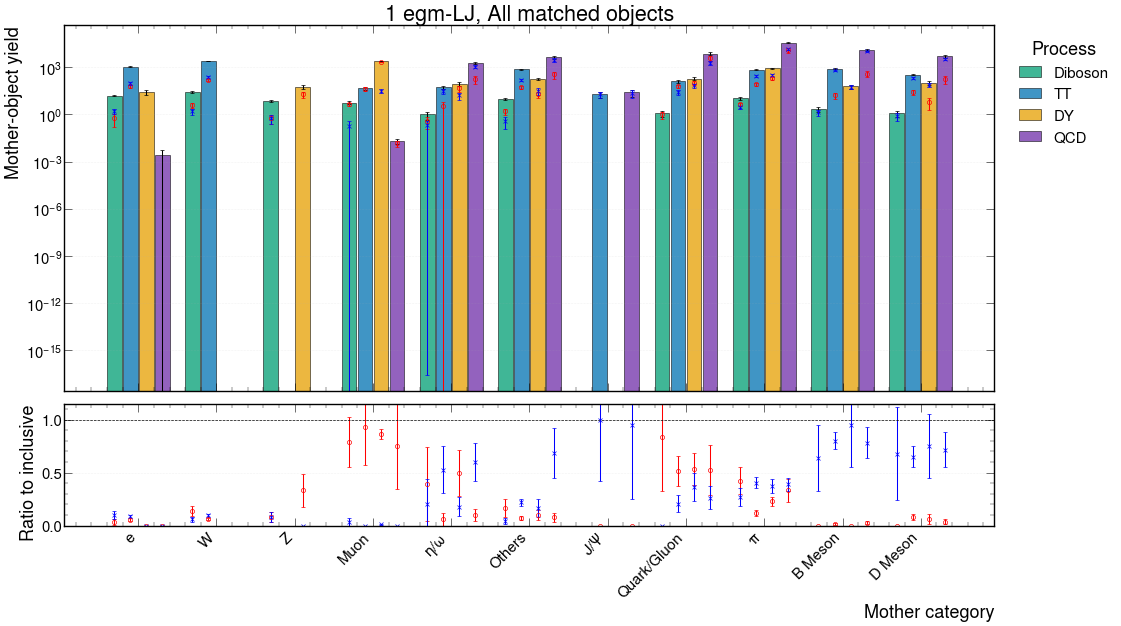

/tmp/ipykernel_2775/524050169.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show(); plt.close(fig)


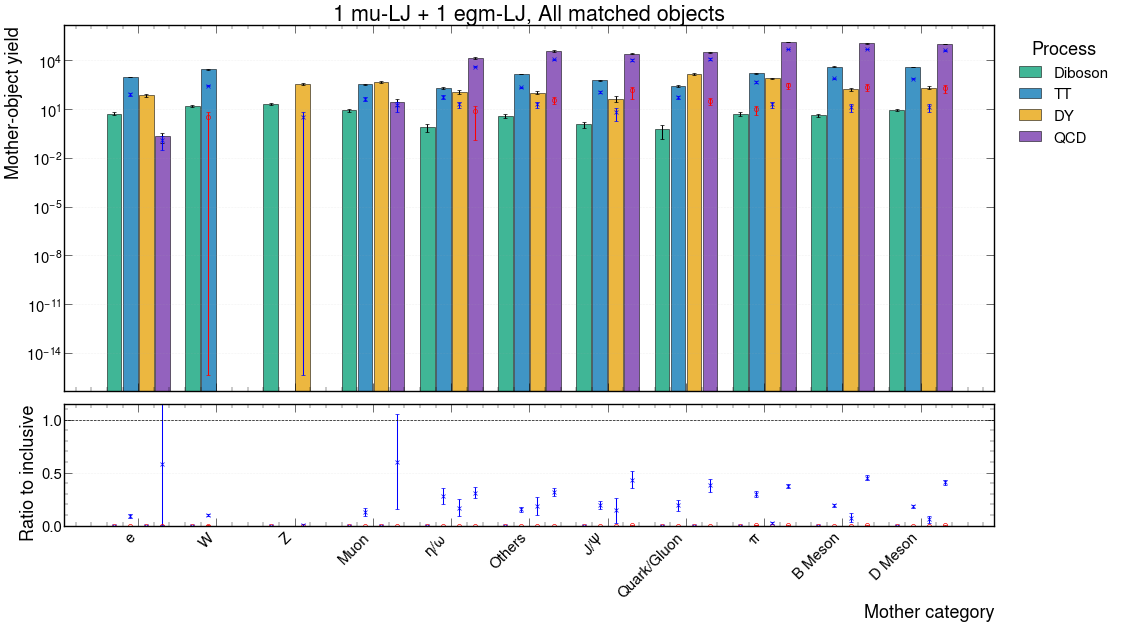

/tmp/ipykernel_2775/524050169.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show(); plt.close(fig)


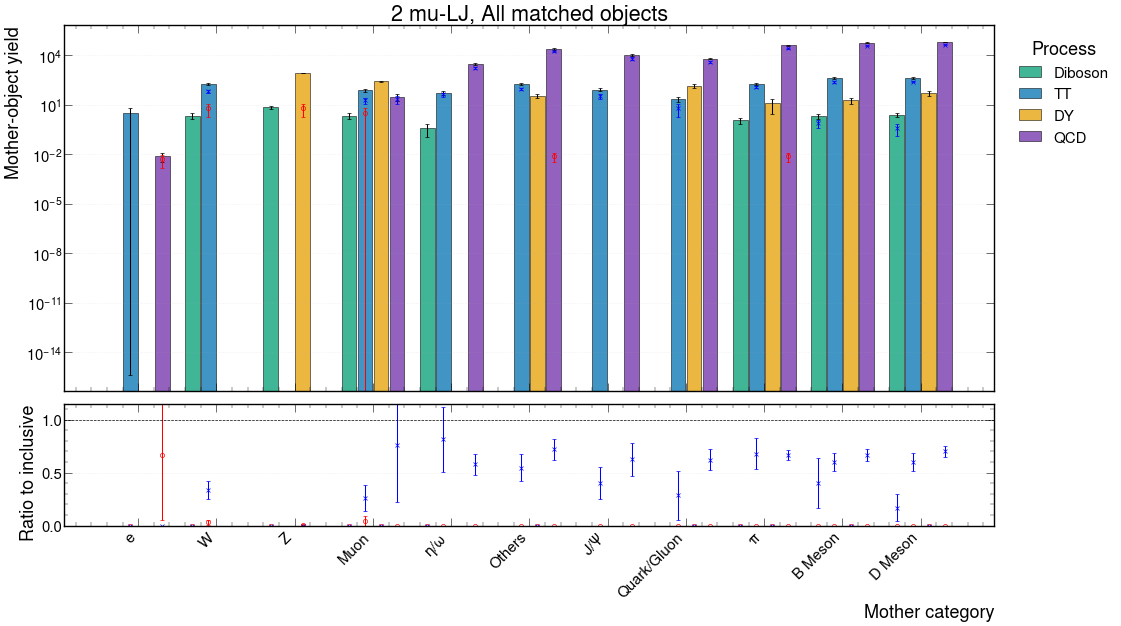

In [10]:
def process_mother_tables(channel_label, histogram_name):
    tables = {}
    errors = {}
    for region in REGION_SUFFIX:
        yield_rows = {}
        error_rows = {}
        for group, samples in BACKGROUND_GROUPS.items():
            series, error = mother_category_table(samples, channel_name(channel_label, region), histogram_name)
            yield_rows[group] = series
            error_rows[group] = error
        tables[region] = pd.DataFrame(yield_rows).T.reindex(columns=MOTHER_STACK_ORDER)
        errors[region] = pd.DataFrame(error_rows).T.reindex(columns=MOTHER_STACK_ORDER)
    return tables, errors


def plot_process_mother_overlay(channel_label, object_label, histogram_name):
    tables, errors = process_mother_tables(channel_label, histogram_name)
    processes = list(BACKGROUND_GROUPS)
    categories = MOTHER_STACK_ORDER
    x = np.arange(len(categories))
    width = 0.82 / len(processes)
    offsets = (np.arange(len(processes)) - (len(processes)-1)/2) * width
    fig, (ax, rax) = plt.subplots(2, 1, figsize=(24, 13), sharex=True,
                                  gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05})
    for index, process in enumerate(processes):
        positions = x + offsets[index]
        inc = tables["Inclusive"].loc[process].to_numpy(float)
        inc_err = errors["Inclusive"].loc[process].to_numpy(float)
        ax.bar(positions, inc, width=0.92*width, color=GROUP_COLORS[process], edgecolor="black", alpha=0.75, label=process)
        mask = inc > 0
        ax.errorbar(positions[mask], inc[mask], yerr=inc_err[mask], fmt="none", ecolor="black", capsize=3)
        for region, marker, color in (("Signal-like", "o", "red"), ("Background-like", "x", "blue")):
            vals = tables[region].loc[process].to_numpy(float)
            errs = errors[region].loc[process].to_numpy(float)
            visible = vals > 0
            ax.errorbar(positions[visible], vals[visible], yerr=errs[visible], marker=marker,
                        markerfacecolor="none" if marker == "o" else color,
                        color=color, ecolor=color, linestyle="none", capsize=3)
            ratio, ratio_error = ratio_uncertainty(vals, errs, inc, inc_err)
            valid = np.isfinite(ratio)
            rax.errorbar(positions[valid], ratio[valid], yerr=ratio_error[valid], marker=marker,
                         markerfacecolor="none" if marker == "o" else color,
                         color=color, ecolor=color, linestyle="none", capsize=3)
    ax.set_yscale("log")
    ax.set(title=f"{channel_label}, {object_label}", ylabel="Mother-object yield")
    ax.grid(axis="y", linestyle=":", alpha=0.3)
    ax.legend(title="Process", bbox_to_anchor=(1.01, 1), loc="upper left")
    rax.axhline(1, color="black", linestyle="--", linewidth=1)
    rax.set(ylabel="Ratio to inclusive", xlabel="Mother category", ylim=(0, 1.15))
    rax.set_xticks(x, categories, rotation=45, ha="right")
    rax.grid(axis="y", linestyle=":", alpha=0.3)
    plt.tight_layout(); plt.show(); plt.close(fig)
    return tables, errors

mother_overlay_tables = {}
# The inclusive matched-object mother histogram is plotted by default.
for channel_label in BASE_CHANNELS:
    mother_overlay_tables[channel_label] = plot_process_mother_overlay(
        channel_label, "All matched objects", "fs_gen_mother_id"
    )

## 1-LJ vs 2-LJ kinematics

All-background normalized shapes compare the compatible 1-LJ and 2-LJ topologies. Error bars include histogram variances. Underflow and overflow are folded into the visible edge bins before normalization.

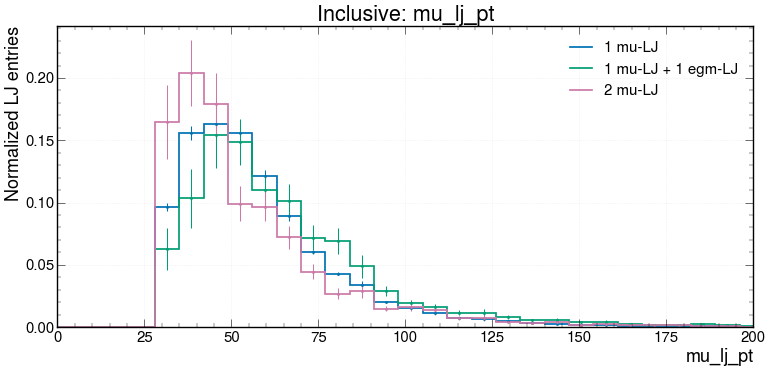

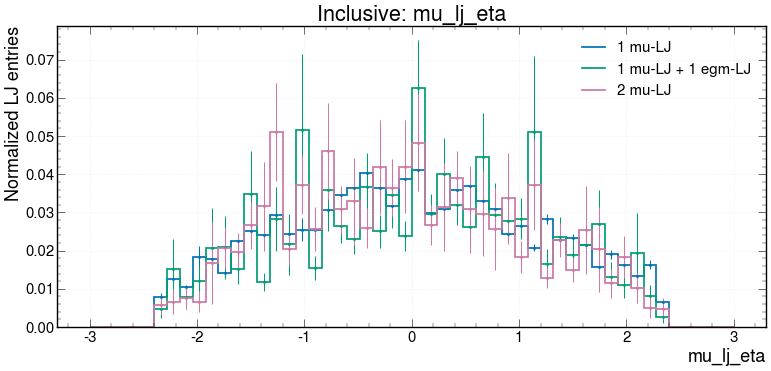

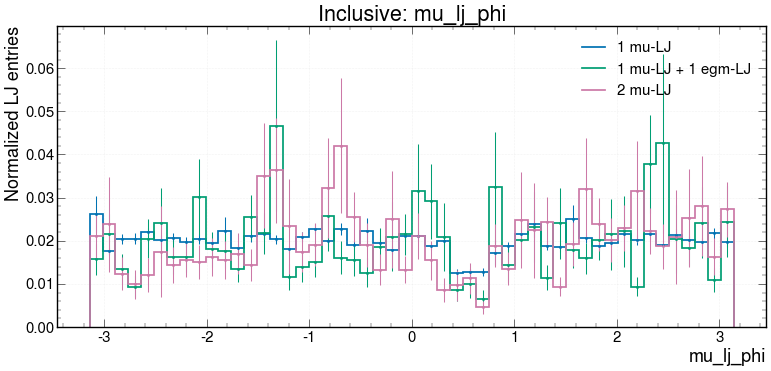

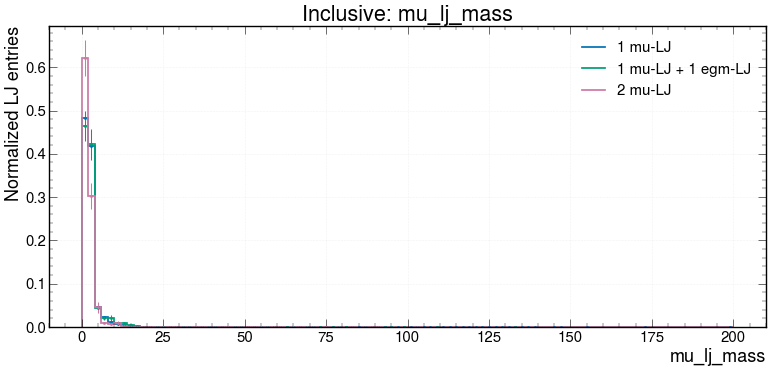

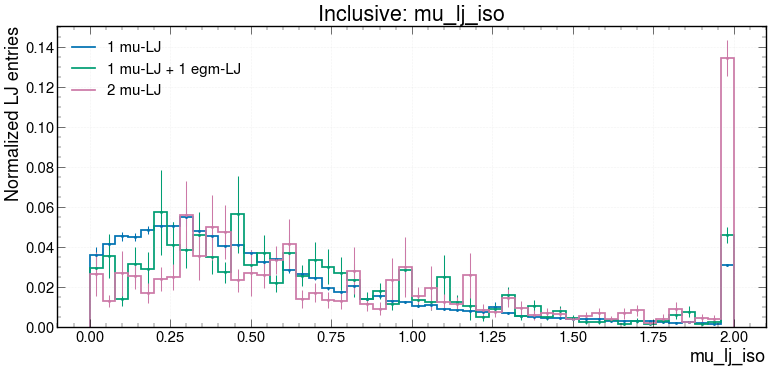

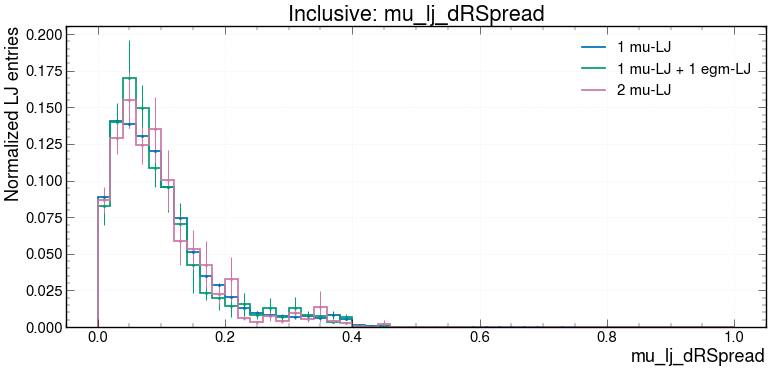

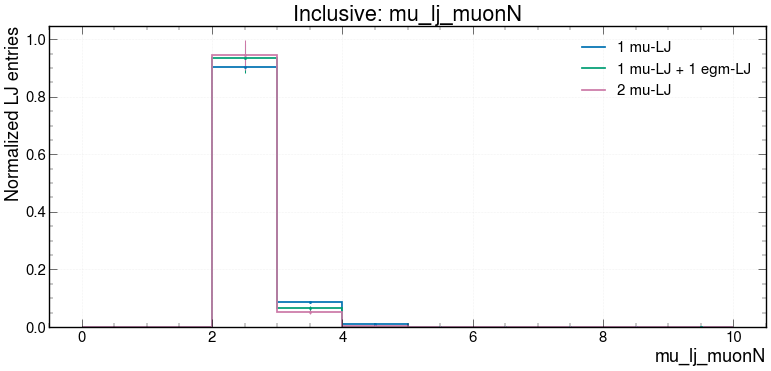

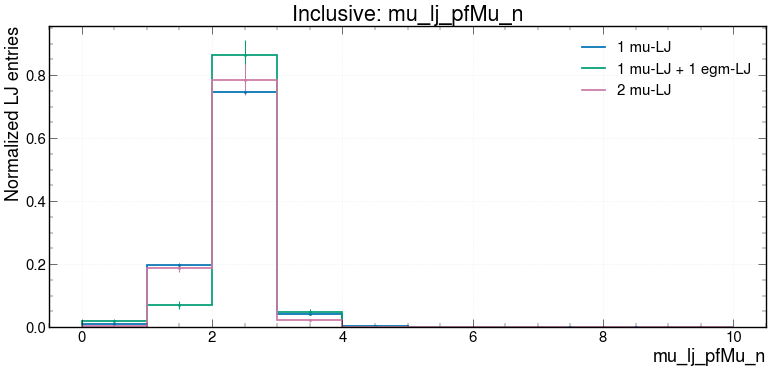

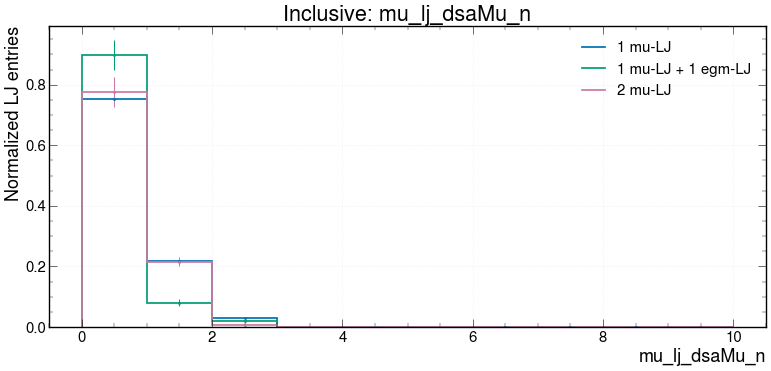

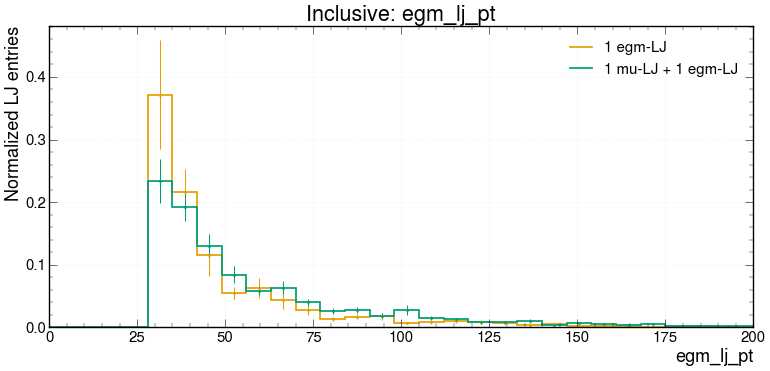

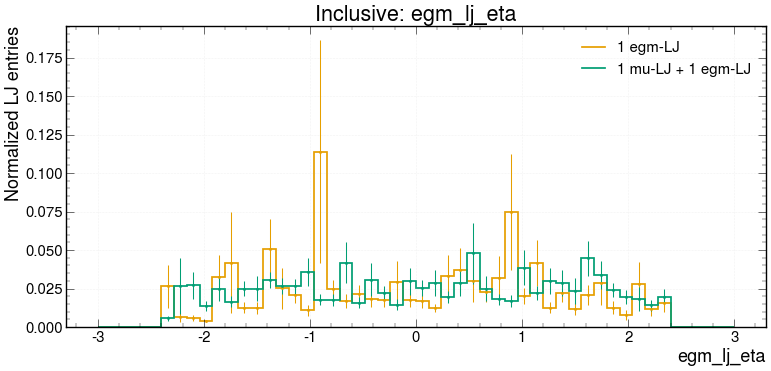

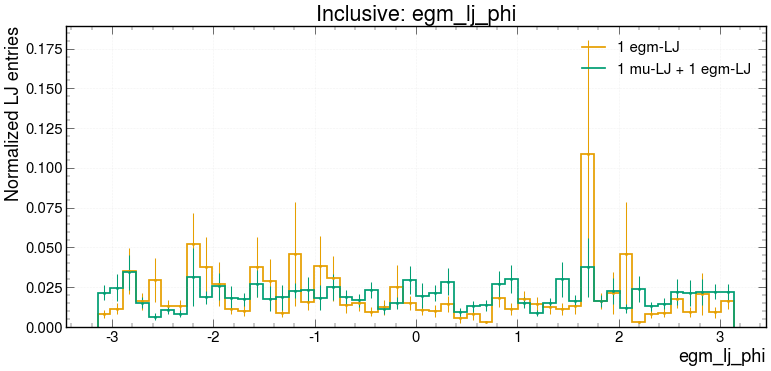

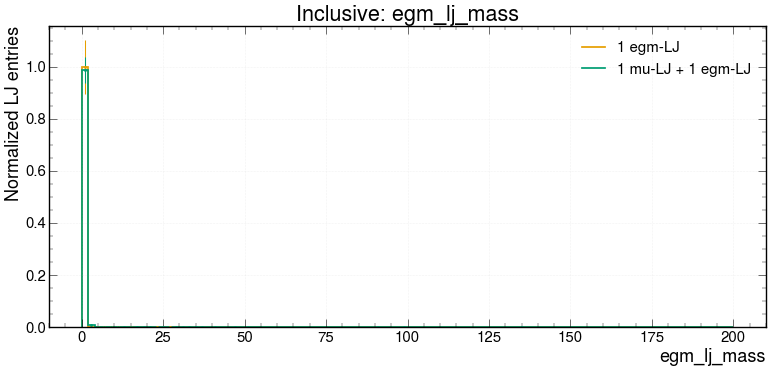

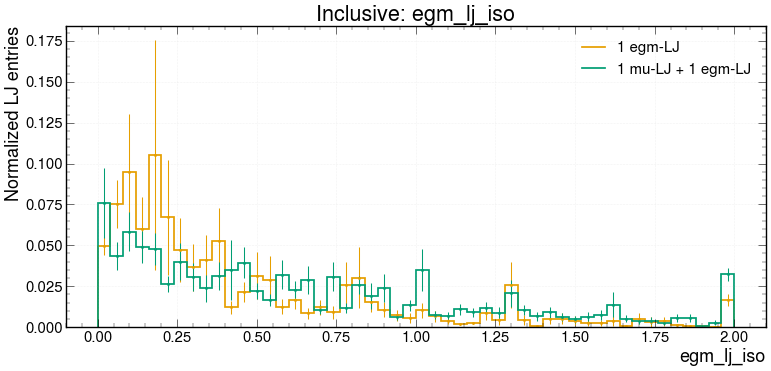

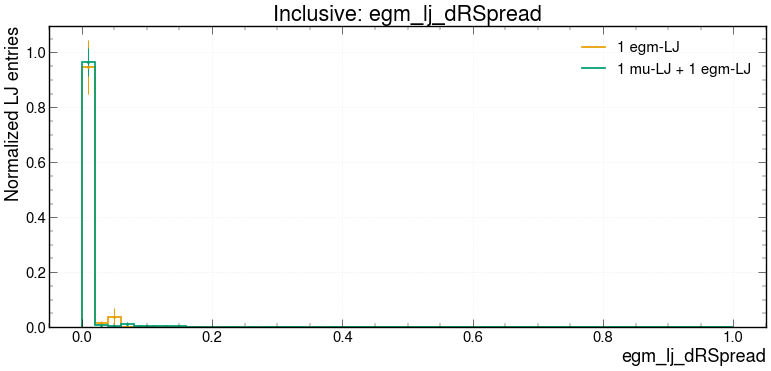

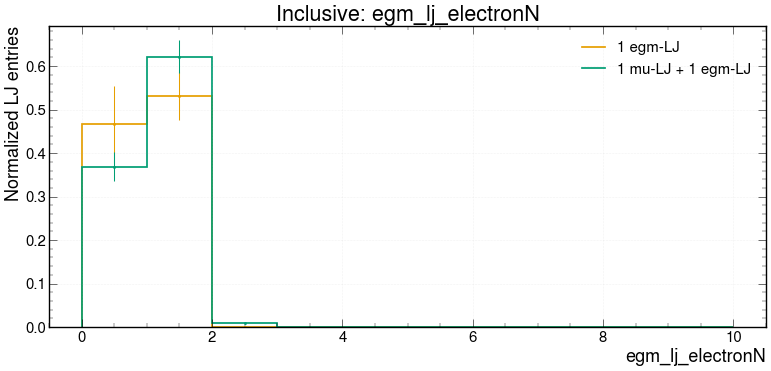

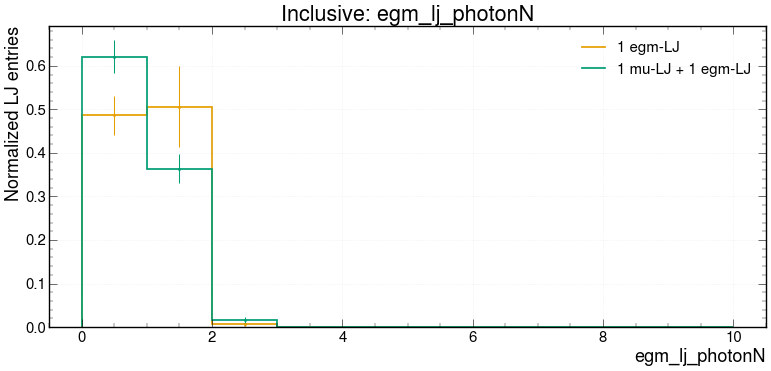

In [11]:
MU_VARIABLES = [
    "mu_lj_pt", "mu_lj_eta", "mu_lj_phi", "mu_lj_mass", "mu_lj_iso",
    "mu_lj_dRSpread", "mu_lj_muonN", "mu_lj_pfMu_n", "mu_lj_dsaMu_n",
]
EGM_VARIABLES = [
    "egm_lj_pt", "egm_lj_eta", "egm_lj_phi", "egm_lj_mass", "egm_lj_iso",
    "egm_lj_dRSpread", "egm_lj_electronN", "egm_lj_photonN",
]
VARIABLE_CHANNELS = {
    **{variable: ["1 mu-LJ", "1 mu-LJ + 1 egm-LJ", "2 mu-LJ"] for variable in MU_VARIABLES},
    **{variable: ["1 egm-LJ", "1 mu-LJ + 1 egm-LJ"] for variable in EGM_VARIABLES},
}
PLOT_OPTIONS = {
    "mu_lj_pt": {"xlim": (0, 200)}, "egm_lj_pt": {"xlim": (0, 200)},
    "mu_lj_mass_small": {"xlim": (0, 6)}, "egm_lj_mass_small": {"xlim": (0, 6)},
    "mu_lj_dRSpread": {"rebin": 5}, "egm_lj_dRSpread": {"rebin": 5},
}

def finish_shape_axis(ax, xlabel, title, xlim=None):
    ax.set(xlabel=xlabel, ylabel="Normalized LJ entries", title=title)
    if xlim is not None: ax.set_xlim(*xlim)
    ax.grid(linestyle=":", alpha=0.3)
    ax.legend(frameon=False)


def plot_channel_shapes(variable, region="Inclusive", rebin=1, xlim=None):
    fig, ax = plt.subplots(figsize=(16, 8))
    for channel_label in VARIABLE_CHANNELS[variable]:
        histogram, _ = sum_histogram(SAMPLES, channel_name(channel_label, region), variable)
        edges, shape, error = normalized_shape(histogram, rebin=rebin)
        color = CHANNEL_COLORS[channel_label]
        ax.stairs(shape, edges, label=channel_label, color=color, linewidth=2.5)
        centers = 0.5 * (edges[:-1] + edges[1:])
        visible = shape > 0
        ax.errorbar(centers[visible], shape[visible], yerr=error[visible], fmt="o", color=color, markersize=3)
    finish_shape_axis(ax, variable, f"{region}: {variable}", xlim=xlim)
    plt.tight_layout(); plt.show(); plt.close(fig)

for variable in MU_VARIABLES + EGM_VARIABLES:
    plot_channel_shapes(variable, **PLOT_OPTIONS.get(variable, {}))

## Signal-like vs Background-like kinematics

For each compatible channel, compare normalized shapes after the two selections. These plots emphasize shape changes rather than normalization, which is already shown in the yield-ratio section.

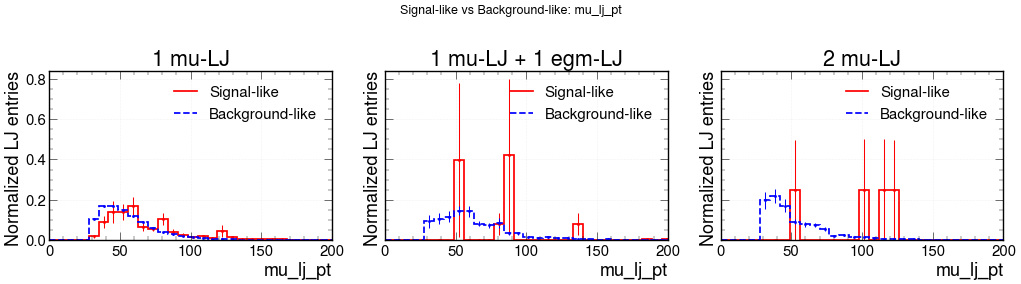

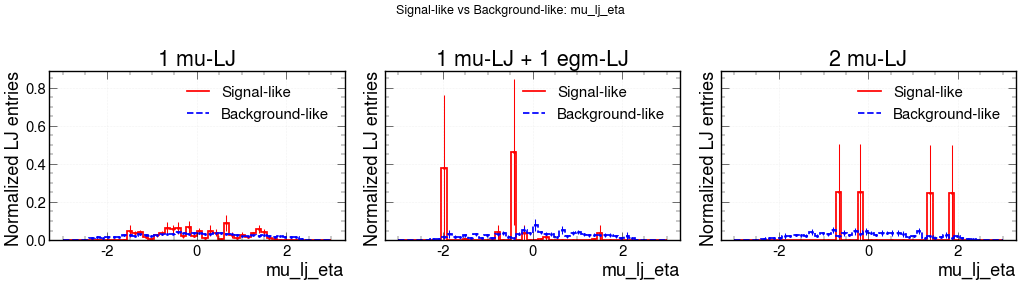

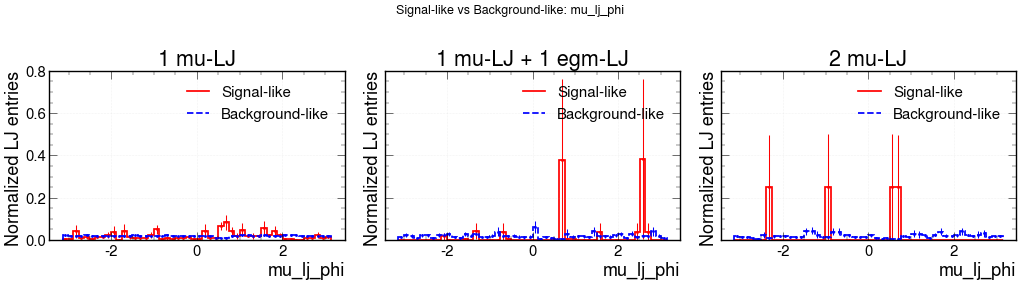

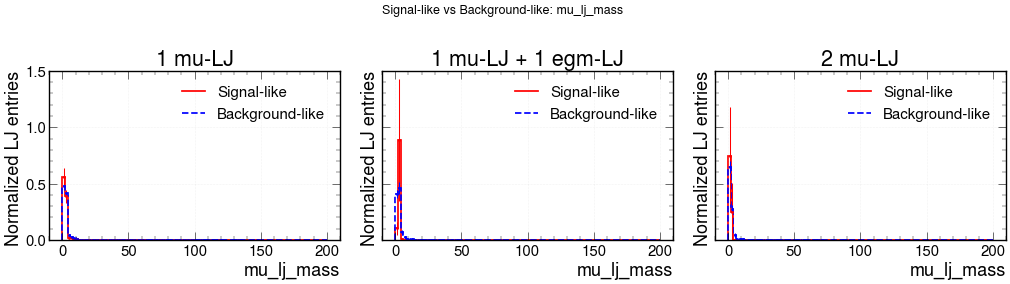

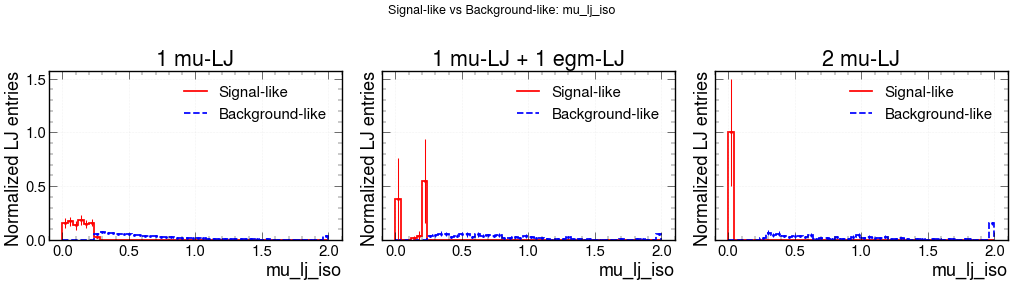

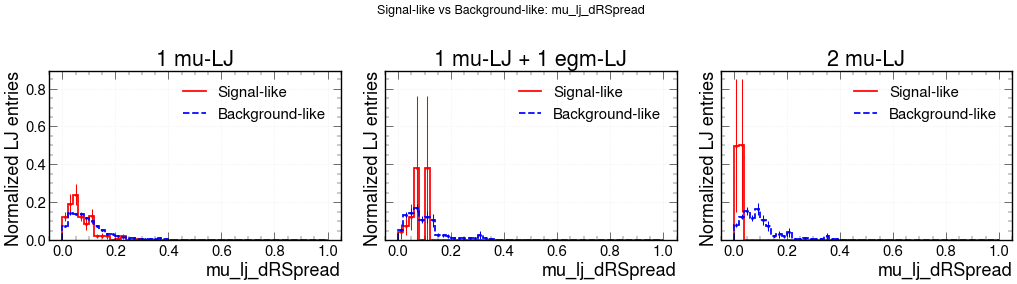

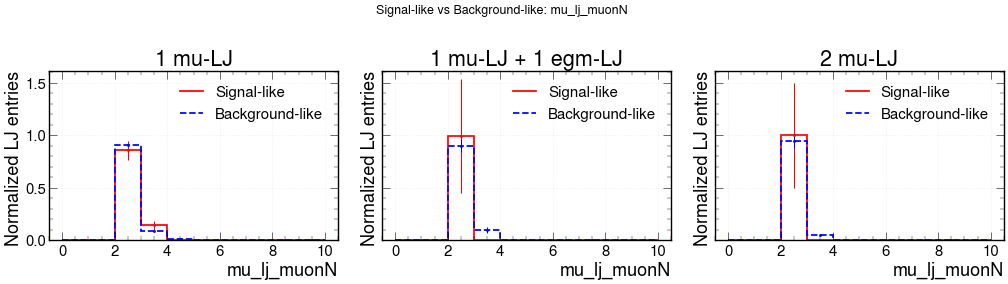

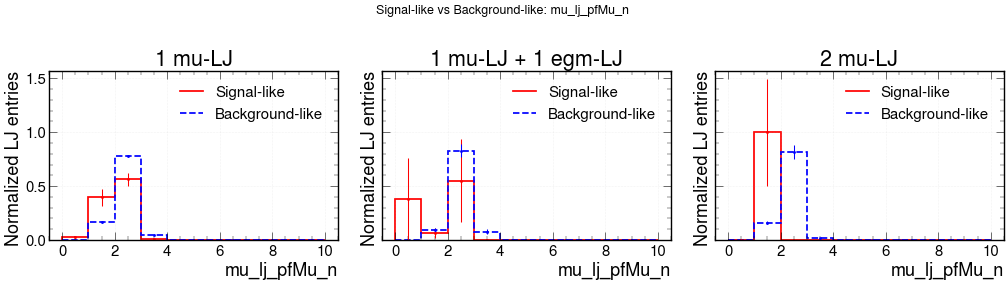

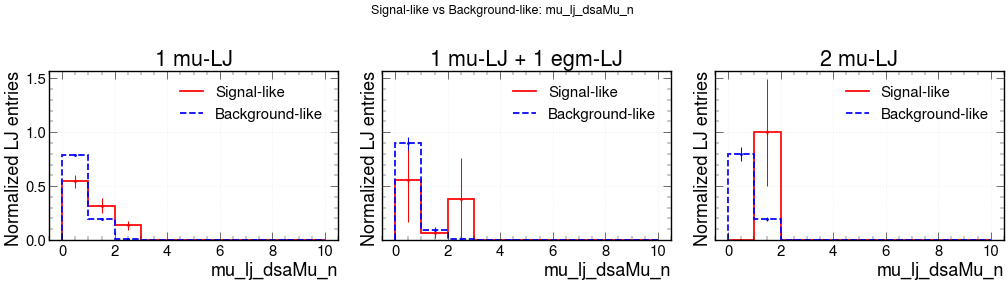

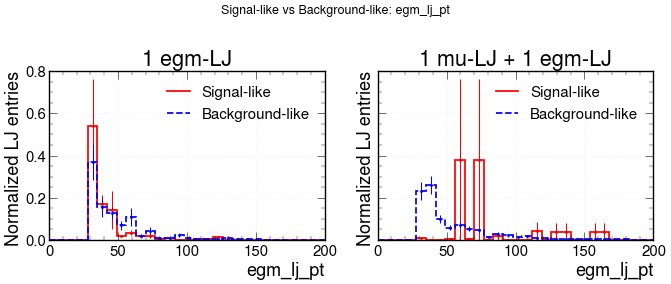

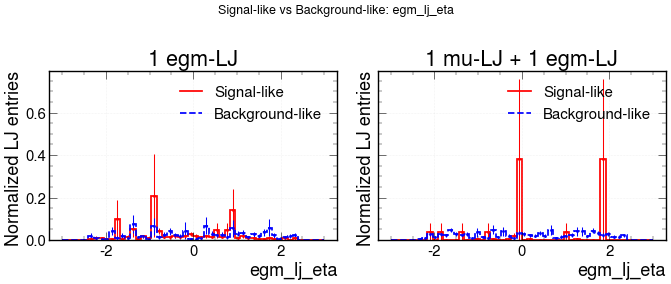

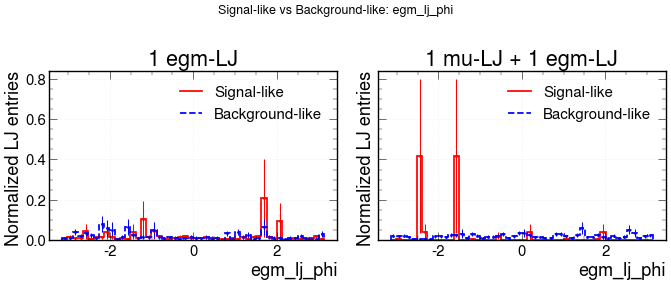

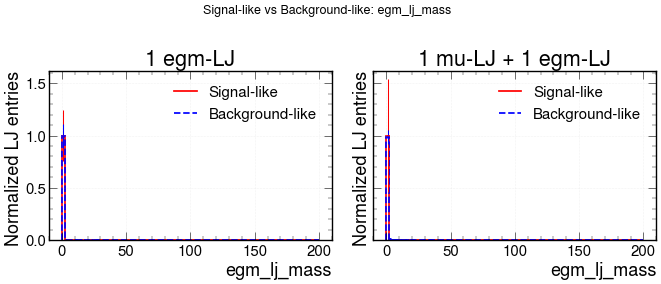

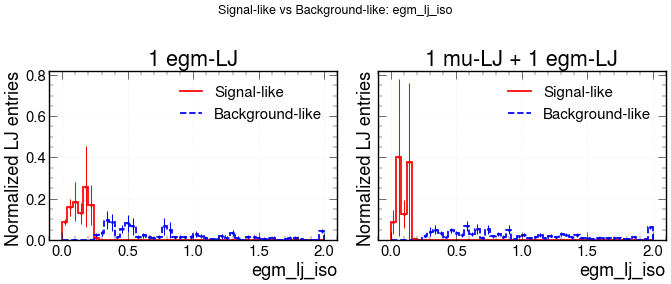

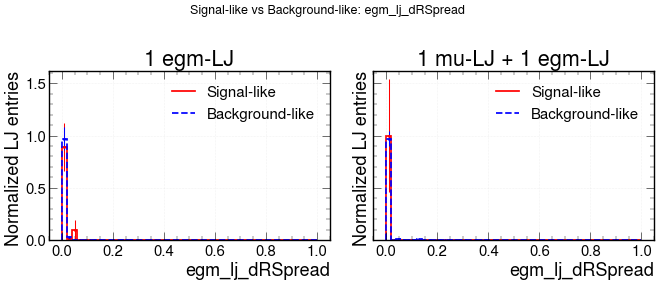

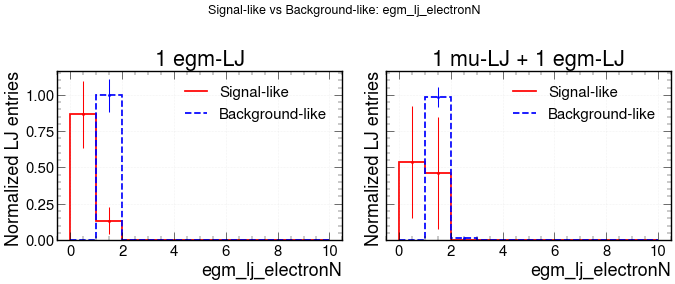

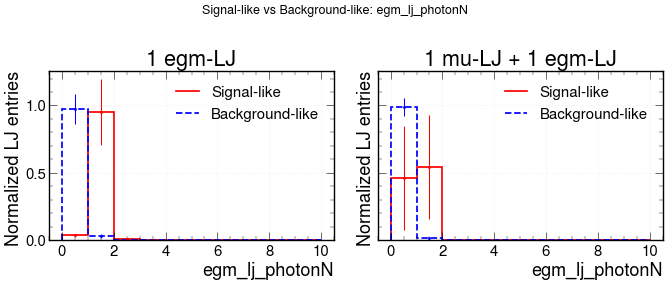

In [12]:
def plot_region_shapes(variable, rebin=1, xlim=None):
    channels = VARIABLE_CHANNELS[variable]
    fig, axes = plt.subplots(1, len(channels), figsize=(7*len(channels), 6), sharey=True)
    axes = np.atleast_1d(axes)
    for ax, channel_label in zip(axes, channels):
        for region in ("Signal-like", "Background-like"):
            histogram, _ = sum_histogram(SAMPLES, channel_name(channel_label, region), variable)
            edges, shape, error = normalized_shape(histogram, rebin=rebin)
            color, linestyle = REGION_STYLES[region]
            ax.stairs(shape, edges, label=region, color=color, linestyle=linestyle, linewidth=2.5)
            centers = 0.5 * (edges[:-1] + edges[1:])
            visible = shape > 0
            ax.errorbar(centers[visible], shape[visible], yerr=error[visible], fmt="o", color=color, markersize=3)
        finish_shape_axis(ax, variable, channel_label, xlim=xlim)
    fig.suptitle(f"Signal-like vs Background-like: {variable}", fontsize=18)
    plt.tight_layout(); plt.show(); plt.close(fig)

for variable in MU_VARIABLES + EGM_VARIABLES:
    plot_region_shapes(variable, **PLOT_OPTIONS.get(variable, {}))

## Optional process-separated kinematics

Set `RUN_PROCESS_SEPARATED_KINEMATICS = True` to produce the same inclusive channel comparison for each background group. It is disabled by default to keep routine notebook execution compact.

In [13]:
RUN_PROCESS_SEPARATED_KINEMATICS = False

if RUN_PROCESS_SEPARATED_KINEMATICS:
    for group, samples in BACKGROUND_GROUPS.items():
        for variable in MU_VARIABLES + EGM_VARIABLES:
            options = PLOT_OPTIONS.get(variable, {})
            fig, ax = plt.subplots(figsize=(16, 8))
            for channel_label in VARIABLE_CHANNELS[variable]:
                histogram, _ = sum_histogram(samples, channel_name(channel_label, "Inclusive"), variable)
                edges, shape, error = normalized_shape(histogram, rebin=options.get("rebin", 1))
                color = CHANNEL_COLORS[channel_label]
                ax.stairs(shape, edges, label=channel_label, color=color, linewidth=2.5)
                centers = 0.5 * (edges[:-1] + edges[1:])
                visible = shape > 0
                ax.errorbar(centers[visible], shape[visible], yerr=error[visible], fmt="o", color=color, markersize=3)
            finish_shape_axis(ax, variable, f"{group}: Inclusive {variable}", xlim=options.get("xlim"))
            plt.tight_layout(); plt.show(); plt.close(fig)

## Compact summary

The tables below collect the main yield ratios for downstream comparison.

In [14]:
summary_rows = []
for channel_label in BASE_CHANNELS:
    yields = channel_process_yields[channel_label]
    for process in BACKGROUND_GROUPS:
        inclusive = yields.loc["Inclusive", process]
        summary_rows.append({
            "channel": channel_label,
            "process": process,
            "inclusive_lj_entry_yield": inclusive,
            "signal_like_fraction": yields.loc["Signal-like", process] / inclusive if inclusive > 0 else np.nan,
            "background_like_fraction": yields.loc["Background-like", process] / inclusive if inclusive > 0 else np.nan,
        })
lj_yield_summary = pd.DataFrame(summary_rows).set_index(["channel", "process"])
display(lj_yield_summary.round(5))

inclusive_lj_entry_yield  signal_like_fraction  \
channel            process                                                   
1 mu-LJ            Diboson              4.941822e+02               0.01747   
                   TT                   1.846669e+04               0.00585   
                   DY                   8.034449e+04               0.02955   
                   QCD                  9.332675e+06               0.01019   
1 egm-LJ           Diboson              5.376240e+01               0.26322   
                   TT                   3.463527e+03               0.09357   
                   DY                   4.438157e+03               0.65335   
                   QCD                  3.334619e+04               0.34594   
1 mu-LJ + 1 egm-LJ Diboson              1.776375e+01               0.00000   
                   TT                   2.717133e+03               0.00120   
                   DY                   9.743920e+02               0.00000   
                   QCD                  7.097139e+04               0.00257   
2 mu-LJ            Diboson              7.261390e+00               0.00000   
                   TT                   4.583117e+02               0.01429   
                   DY                   9.920934e+02               0.00655   
                   QCD                  4.988947e+04               0.00000   

                            background_like_fraction  
channel            process                            
1 mu-LJ            Diboson                   0.17329  
                   TT                        0.69278  
                   DY                        0.05185  
                   QCD                       0.68721  
1 egm-LJ           Diboson                   0.10907  
                   TT                        0.22779  
                   DY                        0.10573  
                   QCD                       0.38390  
1 mu-LJ + 1 egm-LJ Diboson                   0.00000  
                   TT                        0.16024  
                   DY                        0.01333  
                   QCD                       0.36428  
2 mu-LJ            Diboson                   0.05693  
                   TT                        0.50000  
                   DY                        0.00000  
                   QCD                       0.67397

## Large mu-LJ eta and phi region-shape comparisons

The standard loop above draws all kinematic variables compactly. The following
cell redraws only mu_lj_eta and mu_lj_phi at a larger size, using the same
Signal-like and Background-like channels, normalization, and uncertainties.
The original histogram binning is preserved.


Saved: /home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/studies/Mother_Tracking/16_mu_lj_eta_region_shapes_large.png


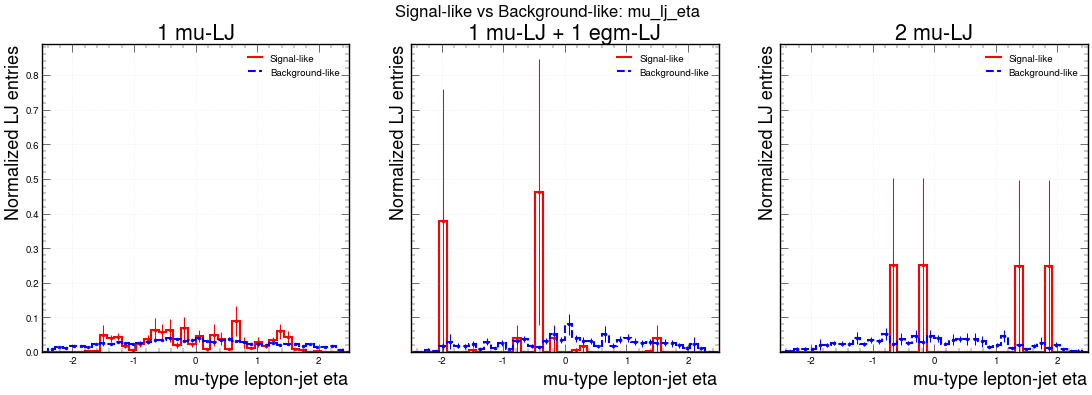

Saved: /home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/studies/Mother_Tracking/16_mu_lj_phi_region_shapes_large.png


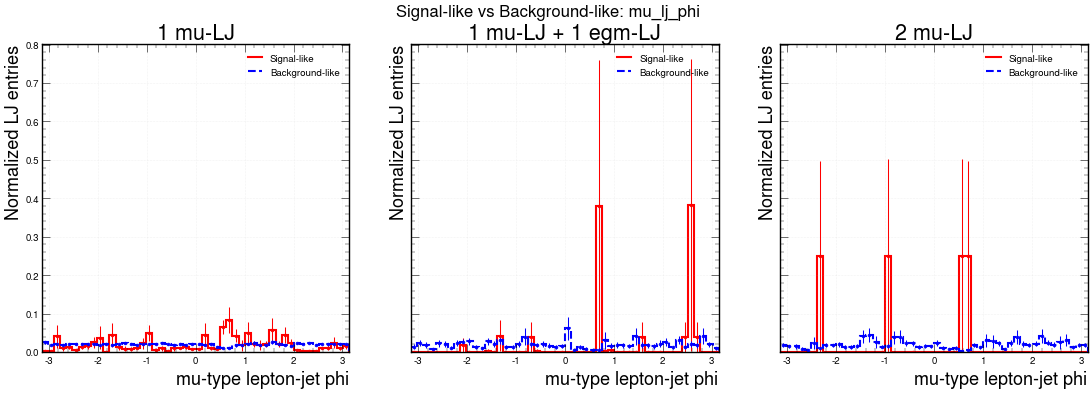

In [15]:
LARGE_MU_LJ_REGION_PLOTS = {
    "mu_lj_eta": {
        "xlim": (-2.5, 2.5),
        "xlabel": r"$mu$-type lepton-jet $eta$",
        "output": study_dir / "16_mu_lj_eta_region_shapes_large.png",
    },
    "mu_lj_phi": {
        "xlim": (-np.pi, np.pi),
        "xlabel": r"$mu$-type lepton-jet $phi$",
        "output": study_dir / "16_mu_lj_phi_region_shapes_large.png",
    },
}


def plot_large_mu_lj_region_shapes(variable, xlim, xlabel, output):
    channels = VARIABLE_CHANNELS[variable]
    fig, axes = plt.subplots(
        1,
        len(channels),
        figsize=(9 * len(channels), 8),
        sharey=True,
    )
    axes = np.atleast_1d(axes)

    for ax, channel_label in zip(axes, channels):
        for region in ("Signal-like", "Background-like"):
            histogram, _ = sum_histogram(
                SAMPLES,
                channel_name(channel_label, region),
                variable,
            )
            edges, shape, error = normalized_shape(histogram, rebin=1)
            color, linestyle = REGION_STYLES[region]
            ax.stairs(
                shape,
                edges,
                label=region,
                color=color,
                linestyle=linestyle,
                linewidth=3,
            )
            centers = 0.5 * (edges[:-1] + edges[1:])
            visible = shape > 0
            ax.errorbar(
                centers[visible],
                shape[visible],
                yerr=error[visible],
                fmt="o",
                color=color,
                markersize=4,
            )

        ax.set(
            xlabel=xlabel,
            ylabel="Normalized LJ entries",
            title=channel_label,
            xlim=xlim,
        )
        ax.tick_params(axis="both", labelsize=14)
        ax.grid(linestyle=":", alpha=0.3)
        ax.legend(frameon=False, fontsize=14)

    fig.suptitle(
        f"Signal-like vs Background-like: {variable}",
        fontsize=24,
    )
    fig.savefig(output, dpi=180, bbox_inches="tight")
    print(f"Saved: {output}")
    plt.show()
    plt.close(fig)


for variable, options in LARGE_MU_LJ_REGION_PLOTS.items():
    plot_large_mu_lj_region_shapes(variable, **options)


# Eta–Phi hotspot and pixel-veto cross-check

The available output contains eta–phi histograms but no missing-inner-hit multiplicity. These plots therefore test geometric compatibility and selection enrichment, not the detector-level cause itself. The reference rectangles follow the 2017 and 2018 regions used in notebook `10`.

In [16]:
ETA_PHI_HISTOGRAMS = {
    "Electron": "electron_eta_phi", "Muon": "muon_eta_phi",
    "Photon": "photon_eta_phi", "DSA muon": "dsaMuon_eta_phi",
    "mu-LJ": "mu_lj_eta_phi", "egm-LJ": "egm_lj_eta_phi",
}
VETO_REGIONS = {
    "2017": {"eta": (1.0, 1.5), "phi": (2.7, np.pi), "color": "red"},
    "2018": {"eta": (0.3, 1.2), "phi": (0.4, 0.8), "color": "magenta"},
}

missing_eta_phi = {
    sample: sorted(set(ETA_PHI_HISTOGRAMS.values()) - set(out[sample]["hists"]))
    for sample in SAMPLES
}
assert not any(missing_eta_phi.values()), f"Missing eta-phi histograms: {missing_eta_phi}"
print("All eta-phi histograms are available in the latest merged outputs.")

All eta-phi histograms are available in the latest merged outputs.


In [17]:
def sum_eta_phi_histogram(samples, channel, histogram_name):
    histogram, _ = sum_histogram(samples, channel, histogram_name)
    return histogram

def eta_phi_arrays(histogram):
    eta_axis, phi_axis = histogram.axes
    values = np.asarray(histogram.values(), dtype=float)
    variances = histogram.variances()
    variances = np.abs(values) if variances is None else np.asarray(variances, dtype=float)
    return np.asarray(eta_axis.edges), np.asarray(phi_axis.edges), values, variances

def draw_map(ax, histogram, title, mode="yield"):
    eta_edges, phi_edges, values, variances = eta_phi_arrays(histogram)
    if mode == "density":
        total = values.sum()
        shown = values / total if total > 0 else np.zeros_like(values)
        mesh = ax.pcolormesh(phi_edges, eta_edges, shown, cmap="viridis", shading="auto")
        label = "Fraction / bin"
    else:
        positive = values[values > 0]
        norm = LogNorm(vmin=max(positive.min(), positive.max()*1e-4), vmax=positive.max()) if positive.size else None
        mesh = ax.pcolormesh(phi_edges, eta_edges, np.clip(values, 0, None), cmap="viridis", norm=norm, shading="auto")
        label = "Weighted entries"
    ax.set(title=title, xlabel=r"$\phi$", ylabel=r"$\eta$", xlim=(-np.pi, np.pi))
    return mesh, label

def region_stats(histogram, spec):
    eta_edges, phi_edges, values, variances = eta_phi_arrays(histogram)
    eta = 0.5 * (eta_edges[:-1] + eta_edges[1:])
    phi = 0.5 * (phi_edges[:-1] + phi_edges[1:])
    mask = ((eta[:, None] >= spec["eta"][0]) & (eta[:, None] <= spec["eta"][1]) &
            (phi[None, :] >= spec["phi"][0]) & (phi[None, :] <= spec["phi"][1]))
    selected = float(values[mask].sum())
    variance = float(variances[mask].sum())
    total = float(values.sum())
    return selected, np.sqrt(max(variance, 0)), total, selected / total if total > 0 else np.nan


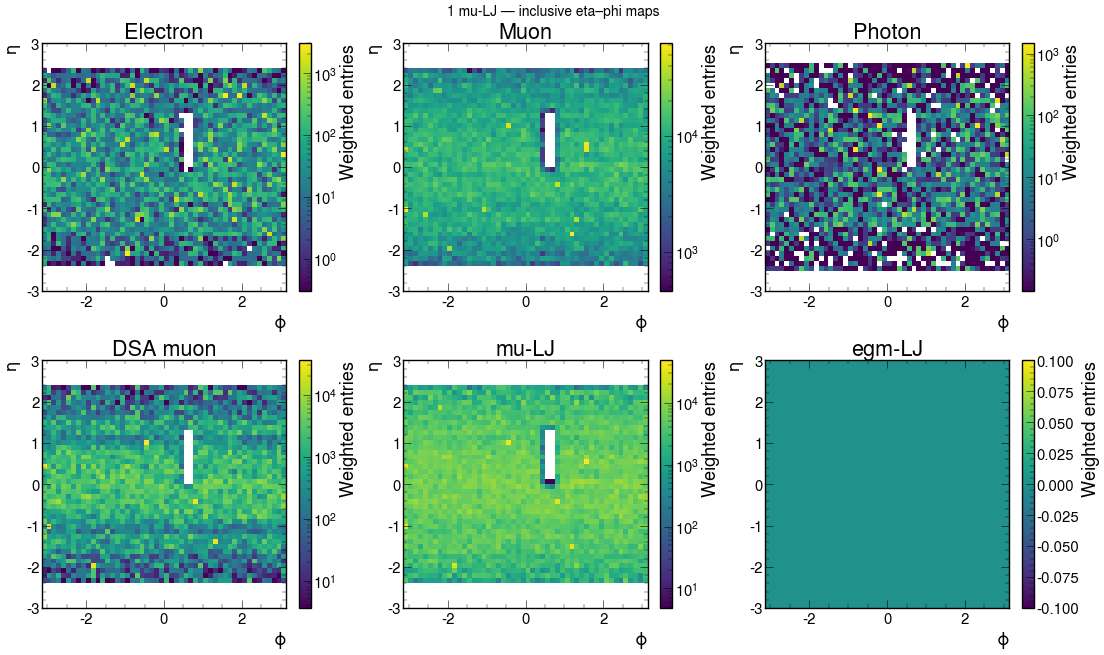

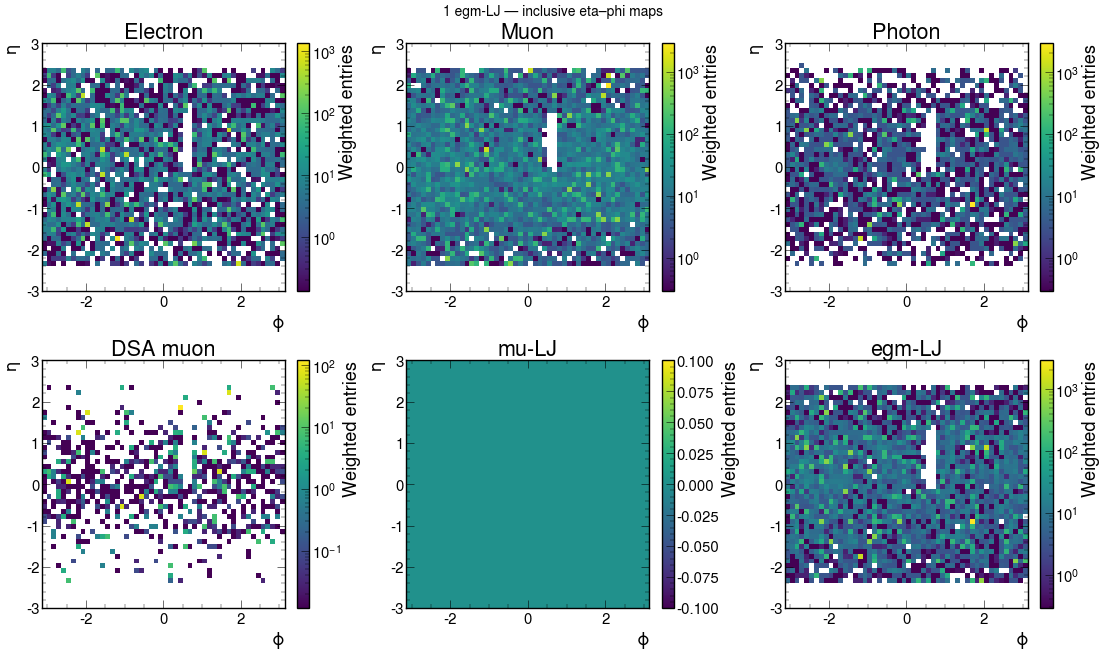

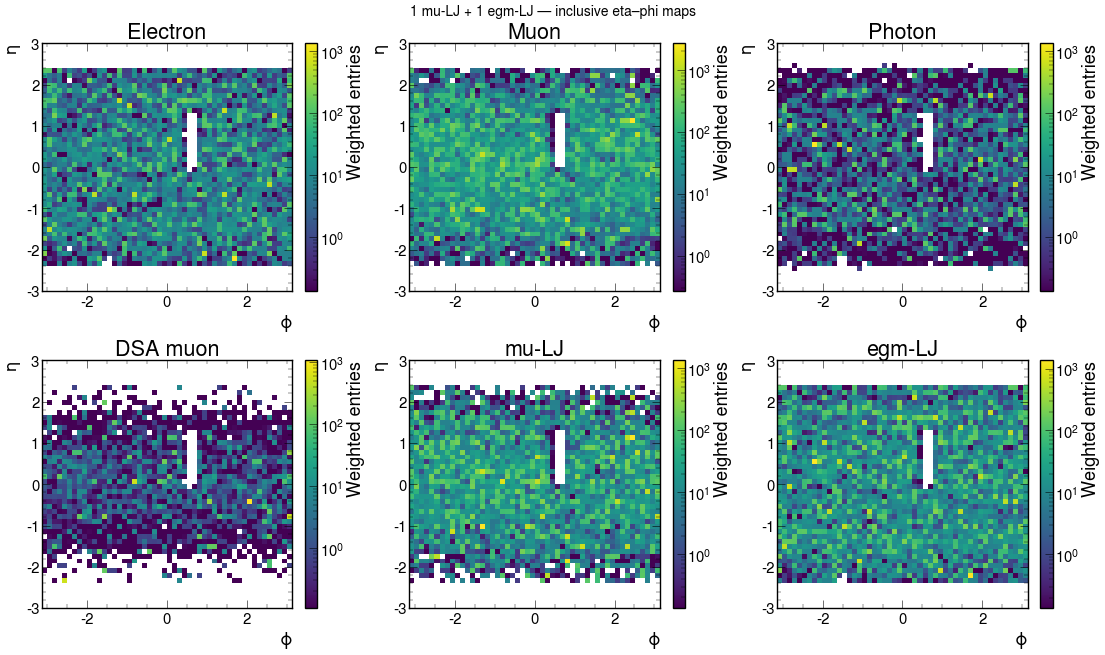

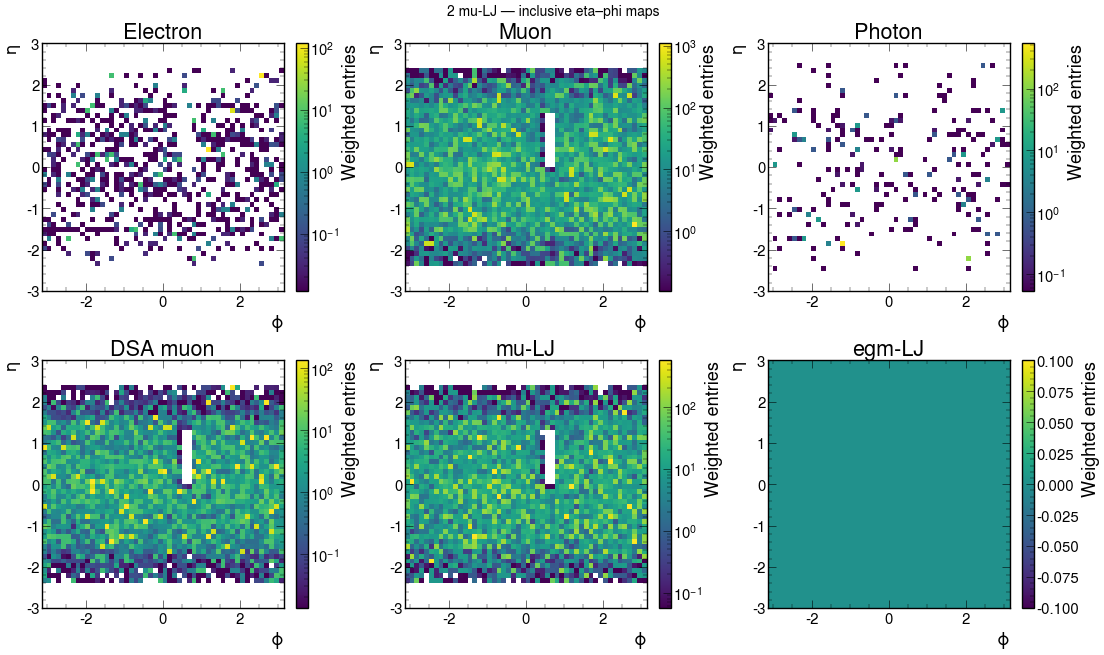

In [18]:
for channel_label in BASE_CHANNELS:
    fig, axes = plt.subplots(2, 3, figsize=(22, 13), constrained_layout=True)
    for ax, (object_label, histogram_name) in zip(axes.flat, ETA_PHI_HISTOGRAMS.items()):
        h = sum_eta_phi_histogram(SAMPLES, channel_name(channel_label, "Inclusive"), histogram_name)
        mesh, cbar_label = draw_map(ax, h, object_label, mode="yield")
        fig.colorbar(mesh, ax=ax, label=cbar_label)
    fig.suptitle(f"{channel_label} — inclusive eta–phi maps", fontsize=20)
    plt.show(); plt.close(fig)

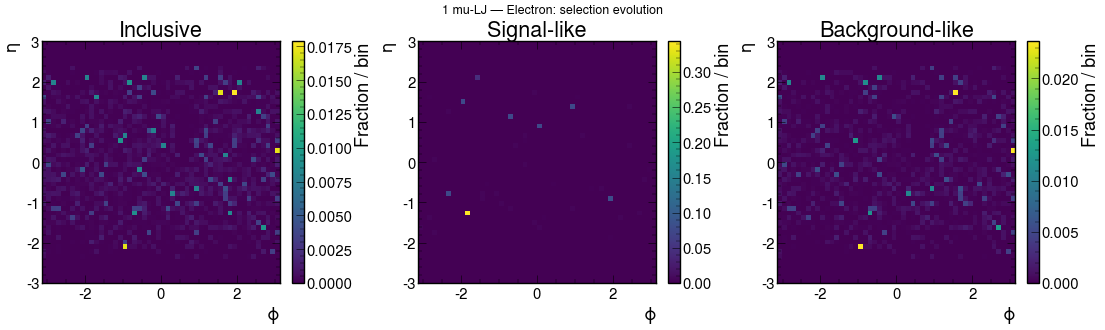

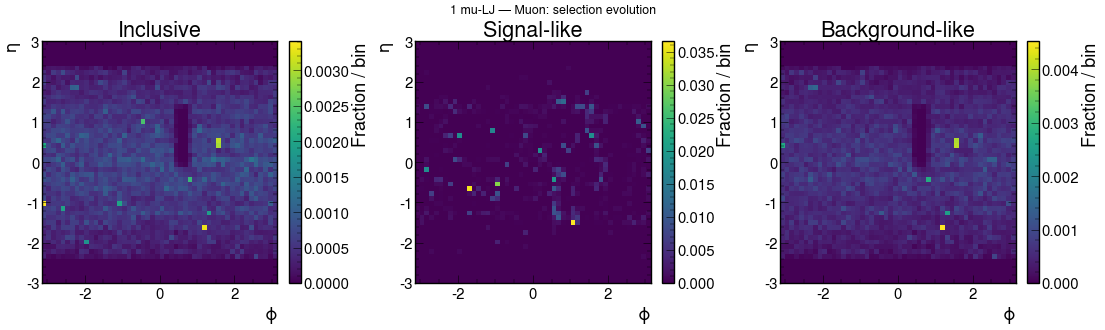

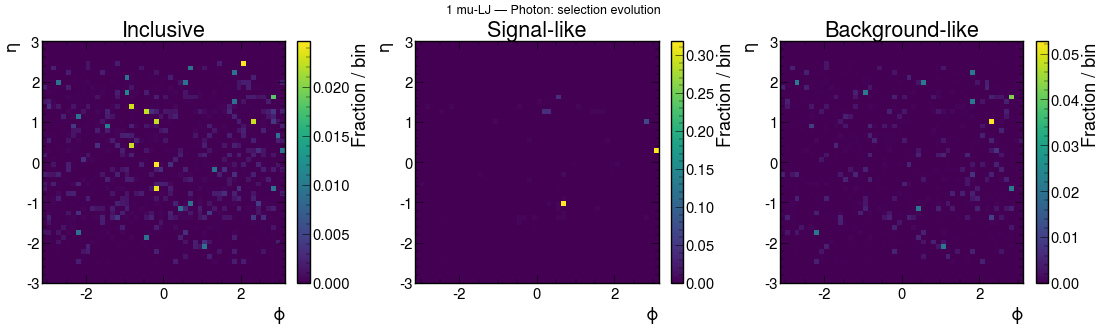

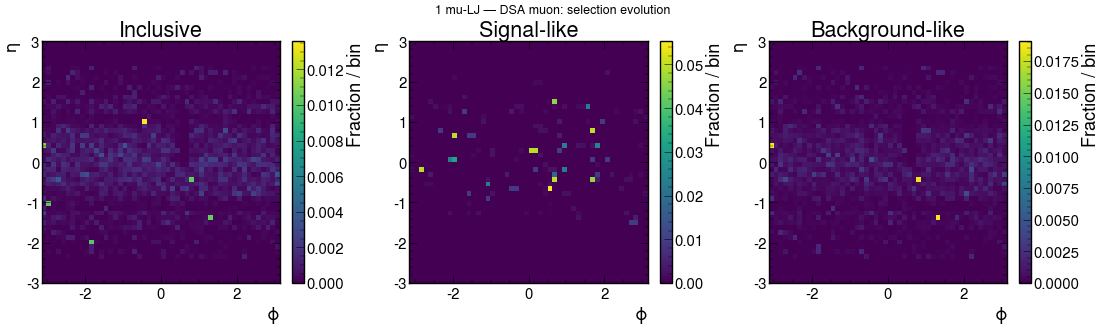

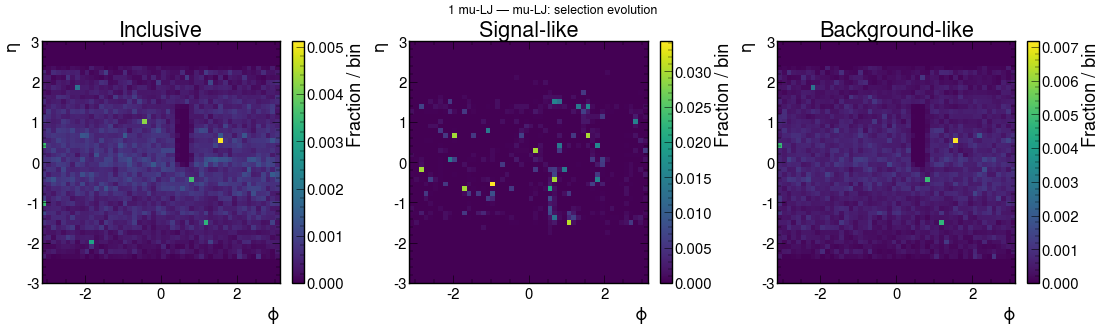

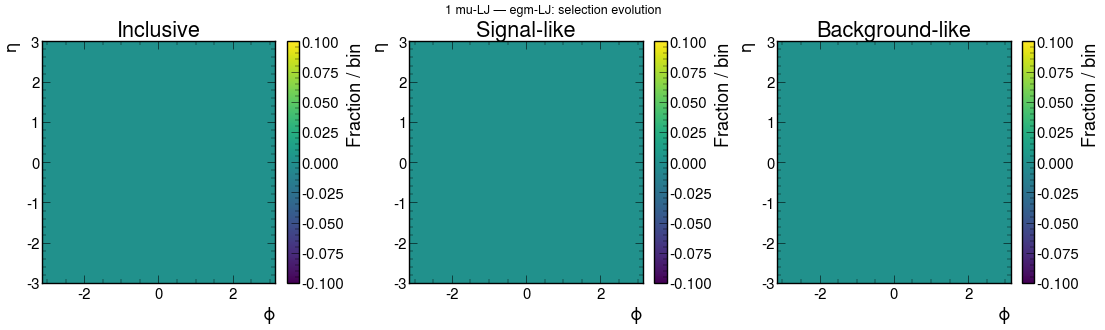

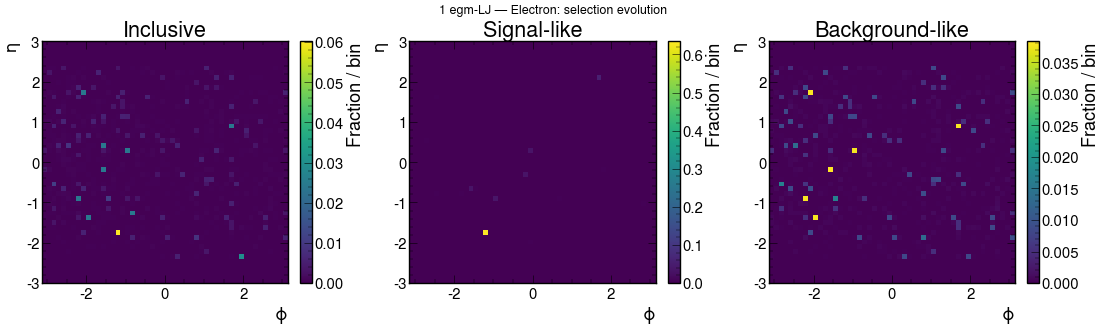

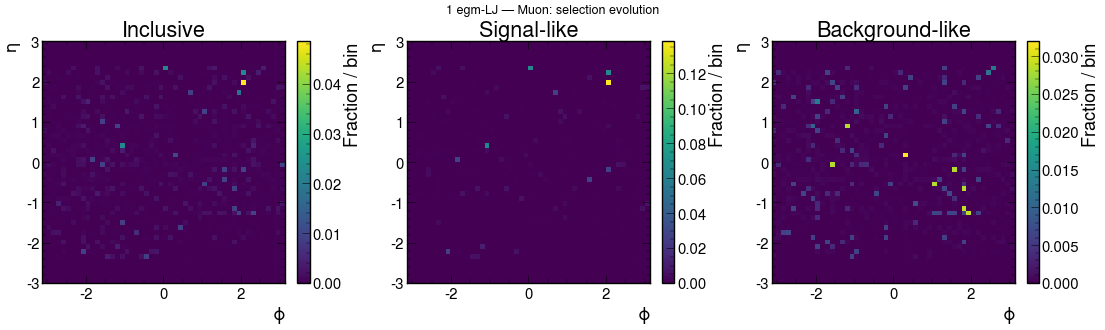

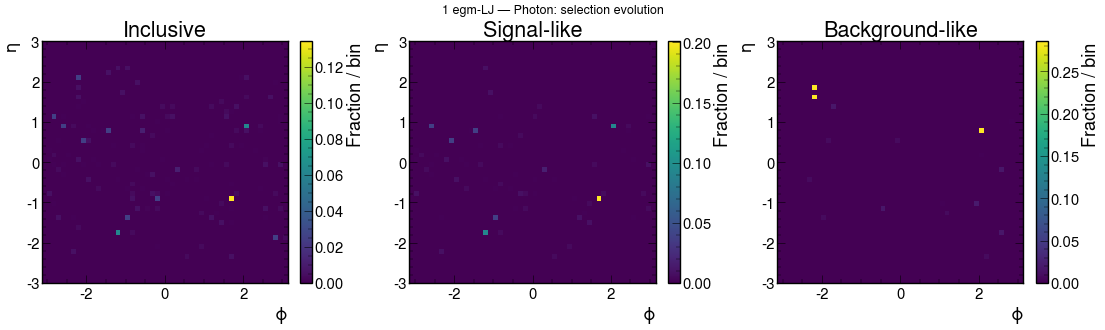

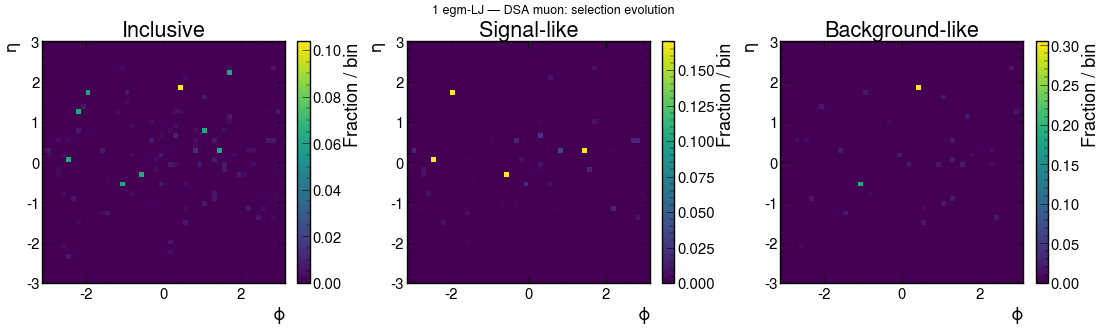

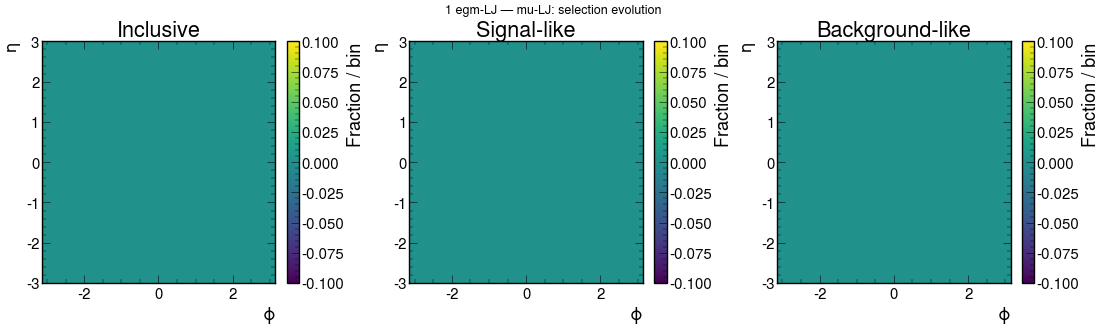

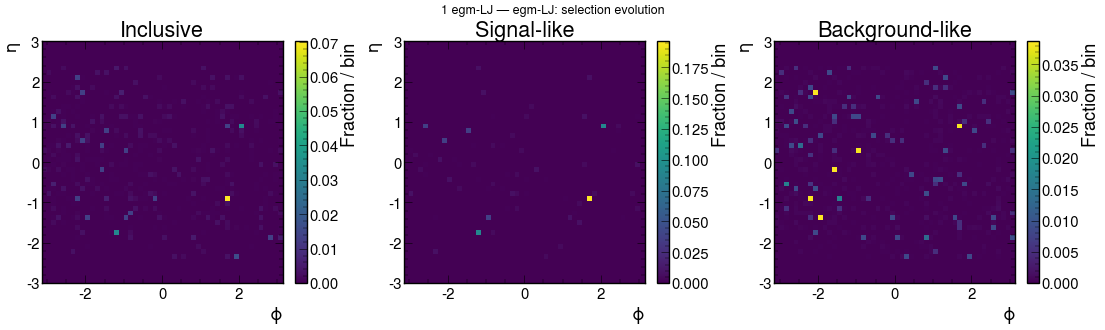

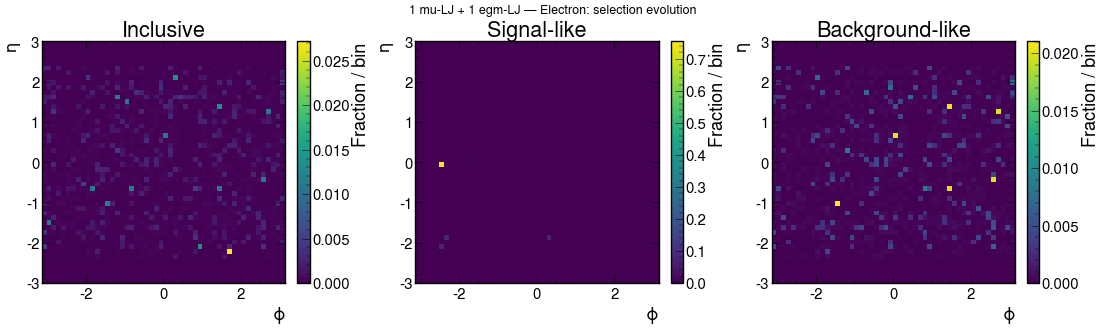

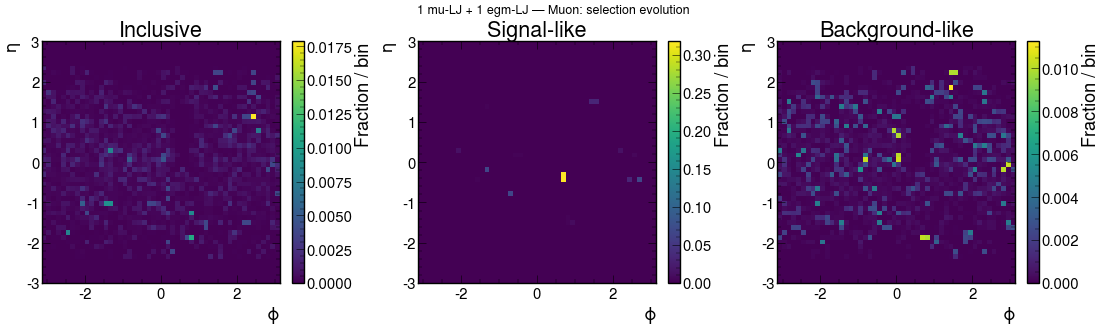

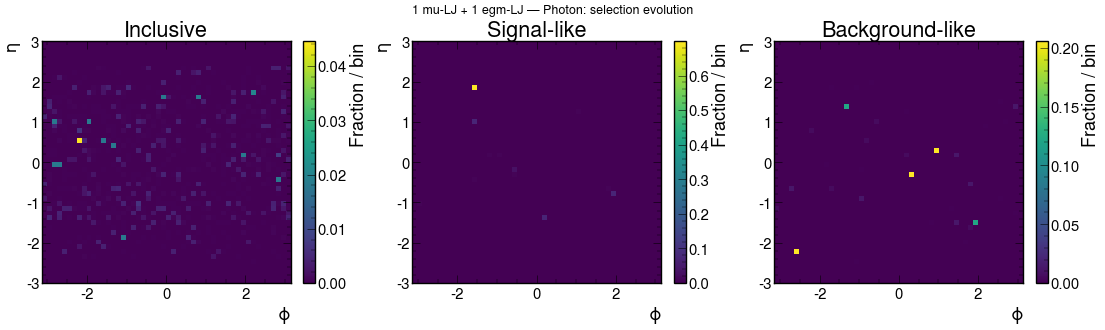

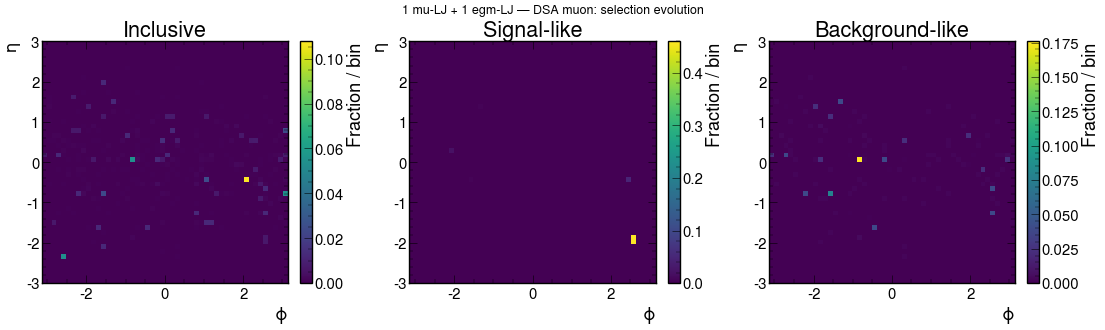

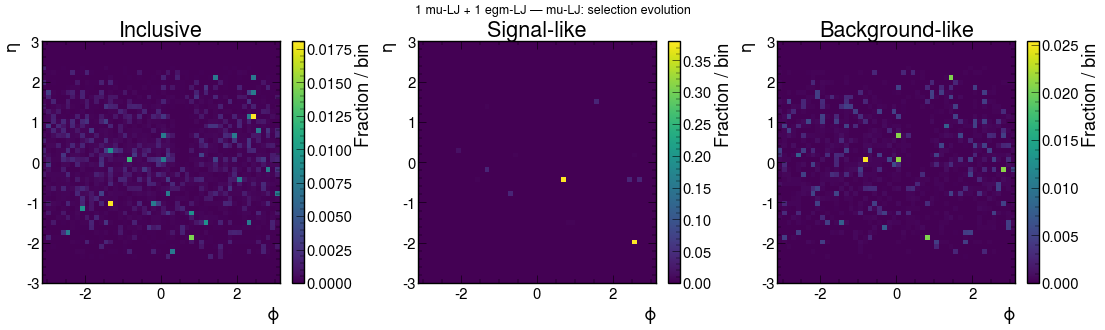

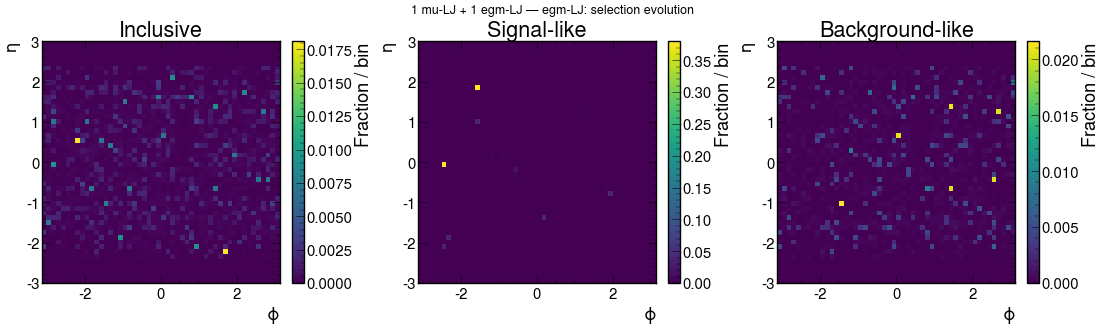

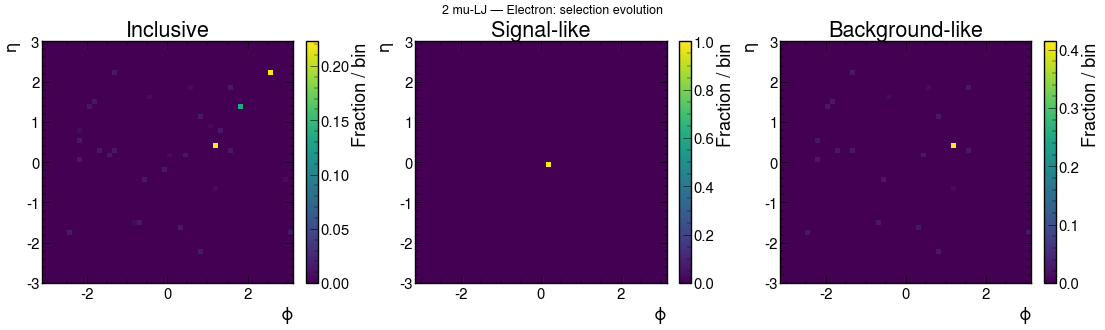

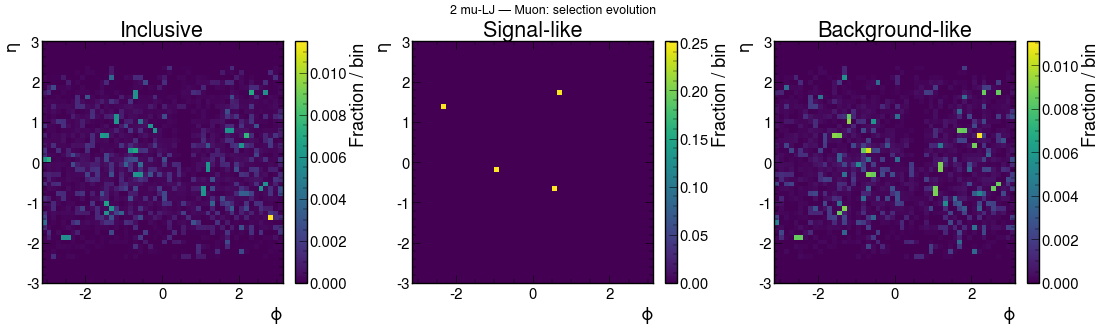

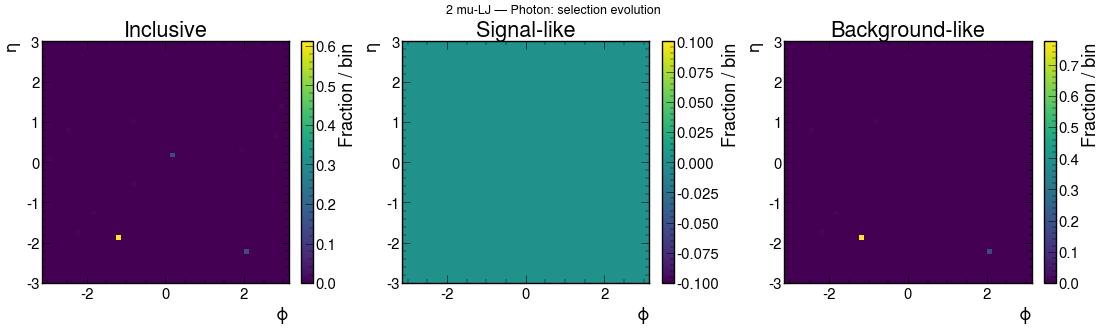

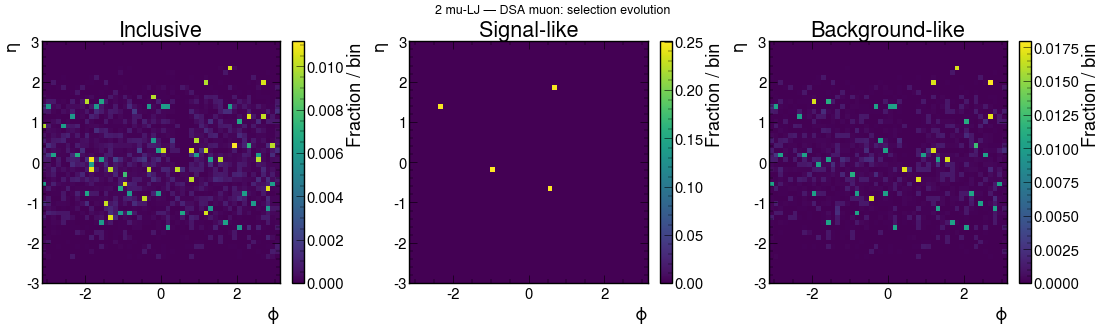

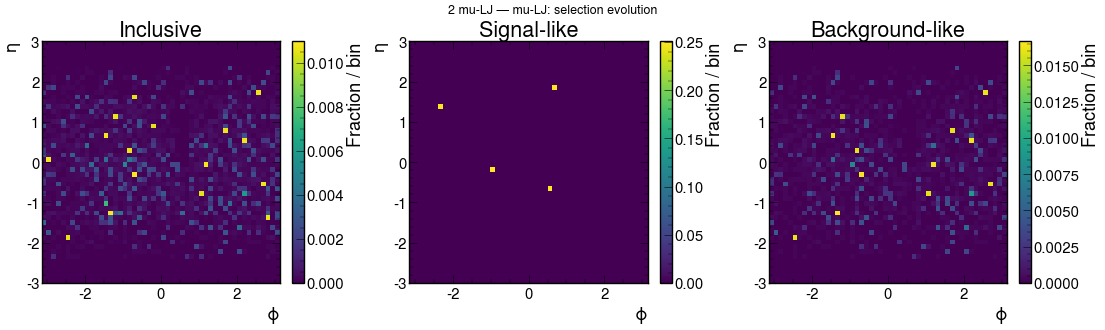

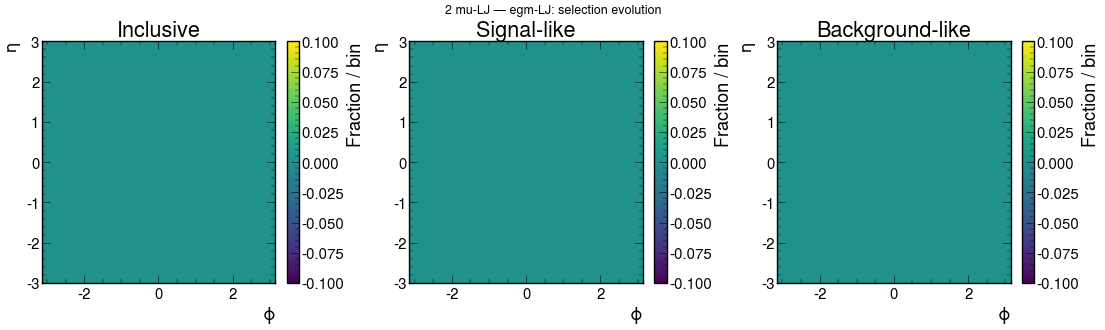

In [19]:
for channel_label in BASE_CHANNELS:
    for object_label, histogram_name in ETA_PHI_HISTOGRAMS.items():
        fig, axes = plt.subplots(1, 3, figsize=(22, 6.5), constrained_layout=True)
        for ax, region in zip(axes, REGION_SUFFIX):
            h = sum_eta_phi_histogram(SAMPLES, channel_name(channel_label, region), histogram_name)
            mesh, cbar_label = draw_map(ax, h, region, mode="density")
            fig.colorbar(mesh, ax=ax, label=cbar_label)
        fig.suptitle(f"{channel_label} — {object_label}: selection evolution", fontsize=18)
        plt.show(); plt.close(fig)

In [20]:
occupancy_rows = []
for channel_label in BASE_CHANNELS:
    for object_label, histogram_name in ETA_PHI_HISTOGRAMS.items():
        fractions = {}
        for region in REGION_SUFFIX:
            h = sum_eta_phi_histogram(SAMPLES, channel_name(channel_label, region), histogram_name)
            for year, spec in VETO_REGIONS.items():
                selected, error, total, fraction = region_stats(h, spec)
                fractions[(region, year)] = fraction
                occupancy_rows.append({
                    "channel": channel_label, "object": object_label, "selection": region,
                    "reference": year, "region yield": selected, "region uncertainty": error,
                    "total yield": total, "region fraction": fraction,
                })
occupancy = pd.DataFrame(occupancy_rows)
fraction_table = occupancy.pivot_table(index=["channel", "object"], columns=["reference", "selection"], values="region fraction")
for year in VETO_REGIONS:
    fraction_table[(year, "pass / inclusive")] = (
        fraction_table[(year, "Signal-like")] / fraction_table[(year, "Inclusive")]
    )
display((100 * fraction_table).round(3).style.format("{:.3f}"))

## Phi projections inside the suspect eta bands

These projections directly test the reported phi bump while controlling eta. Curves are unit-normalized within the indicated eta band.

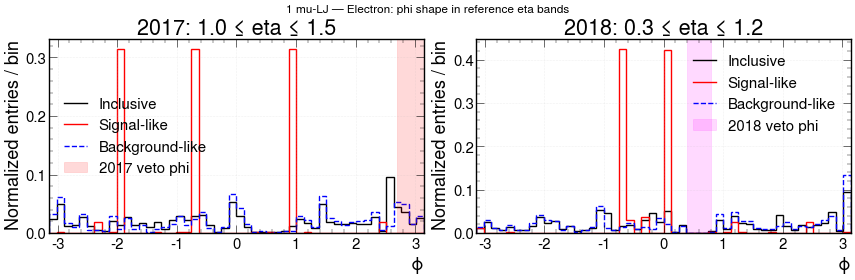

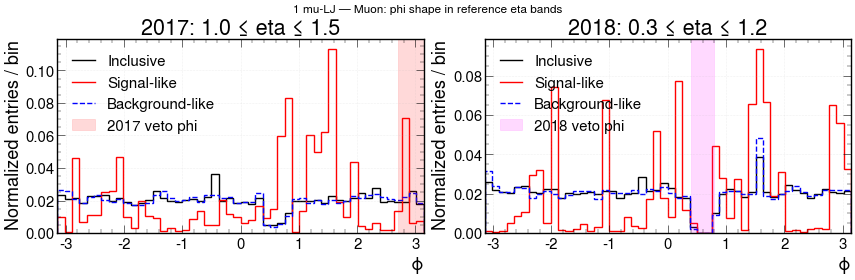

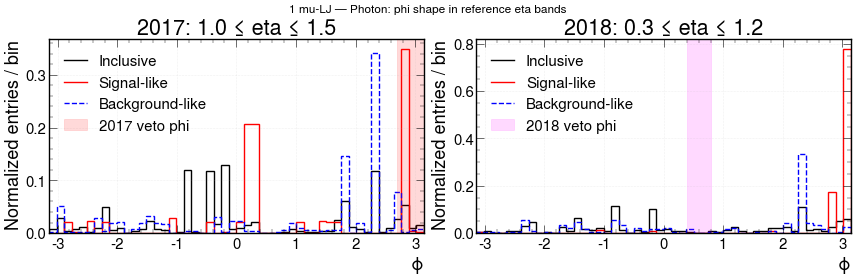

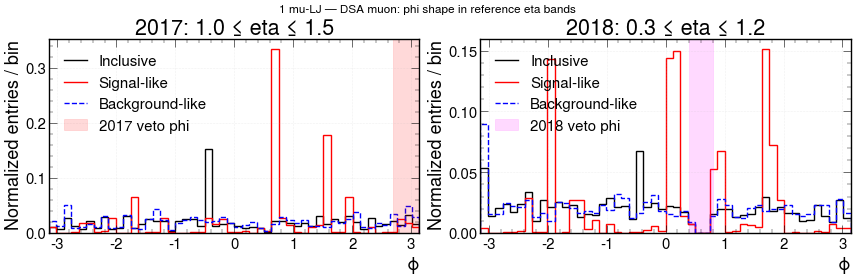

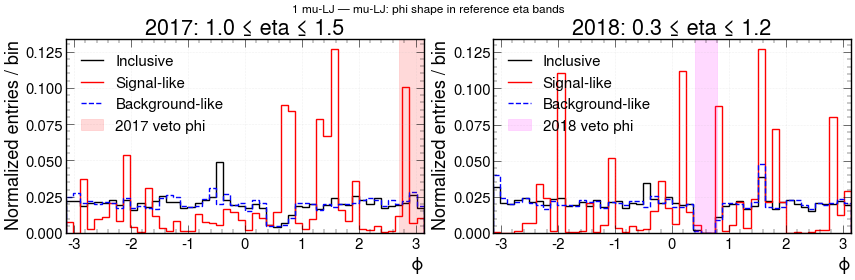

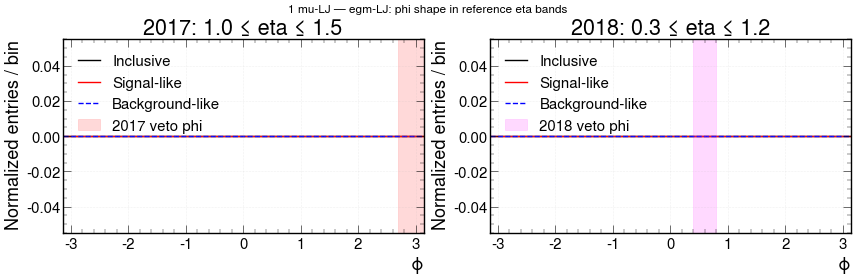

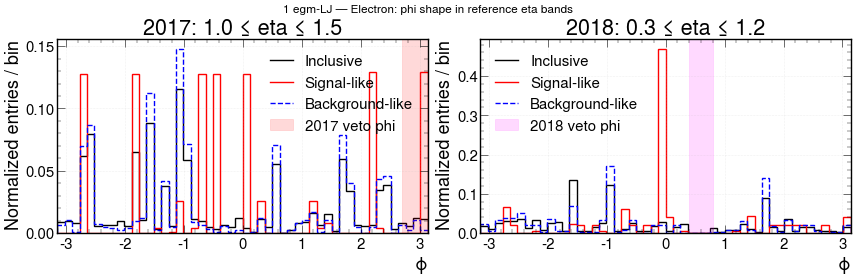

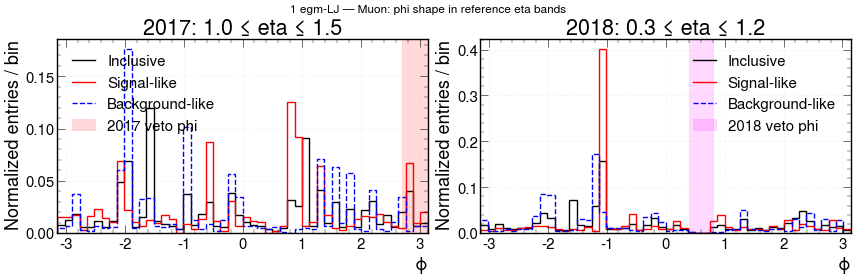

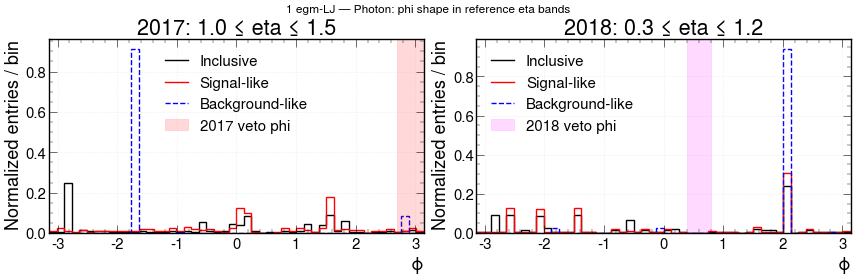

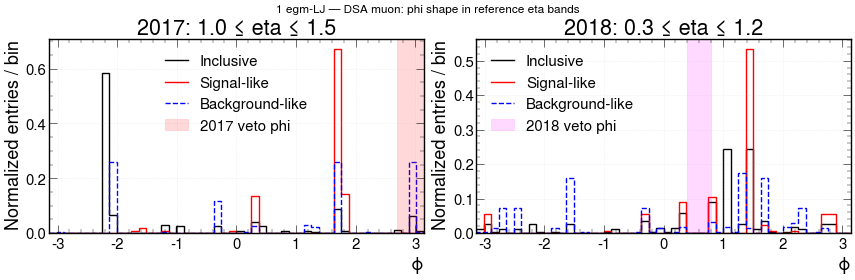

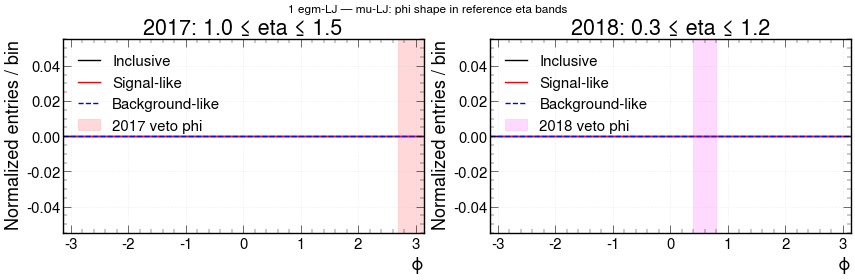

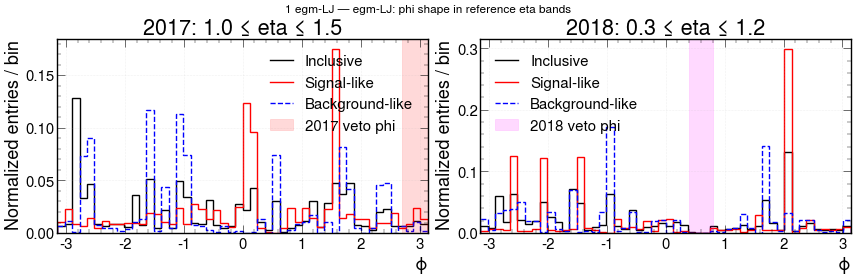

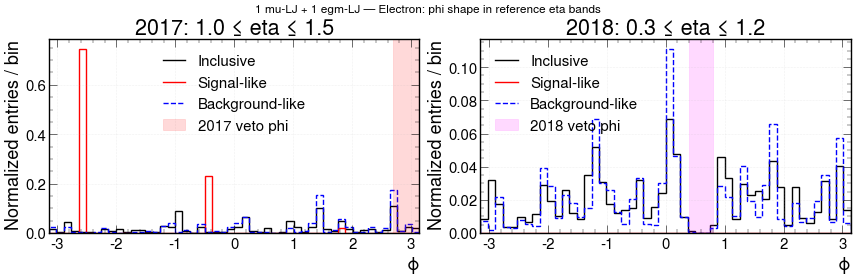

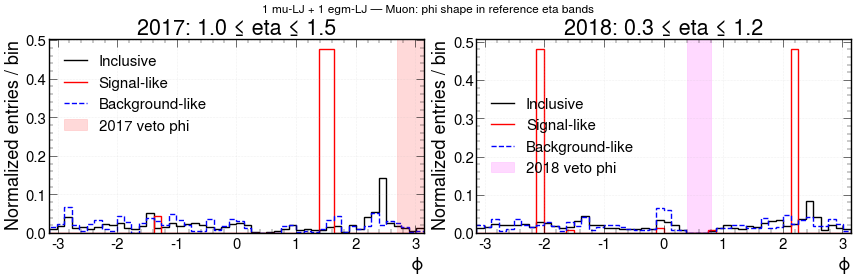

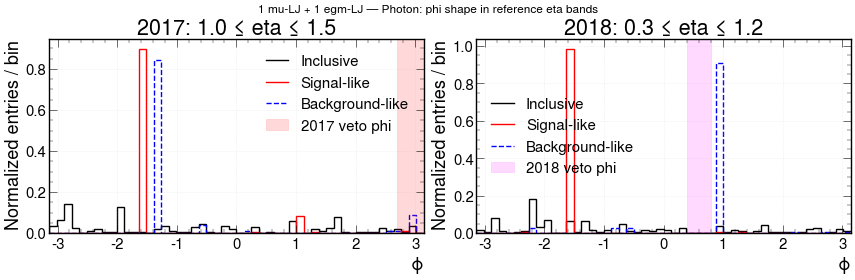

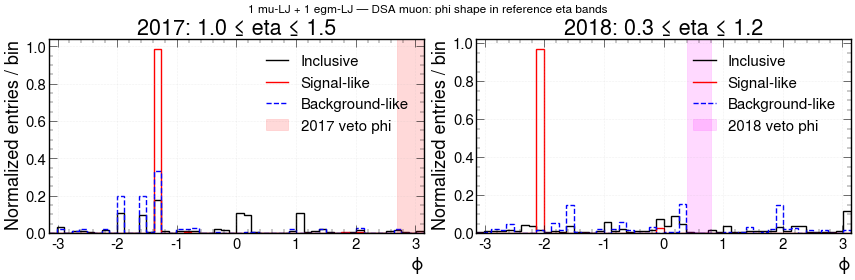

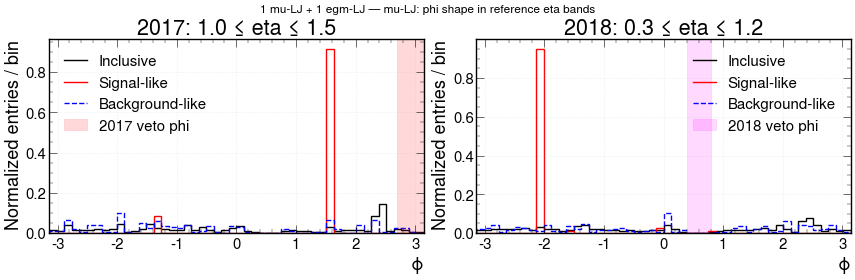

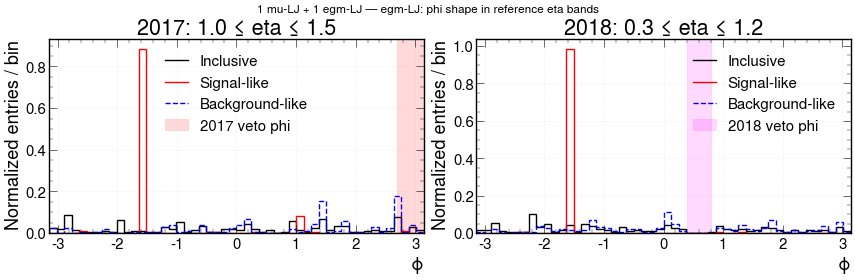

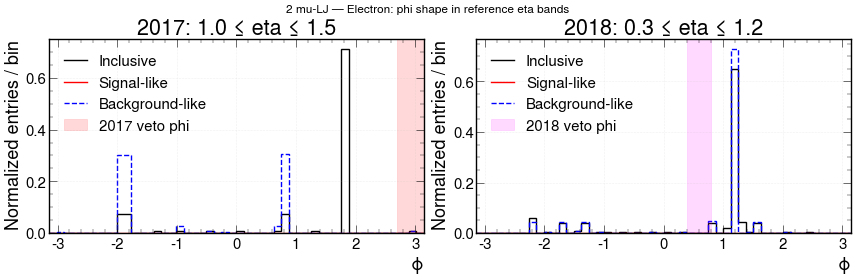

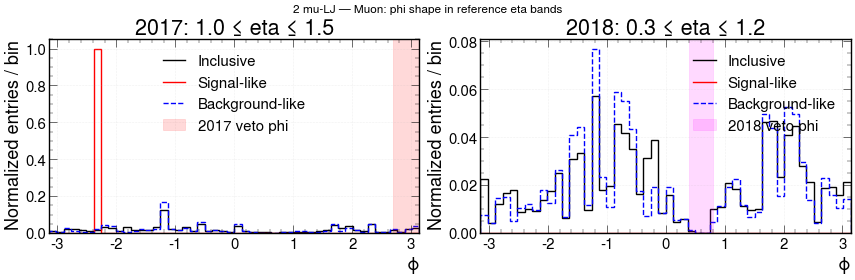

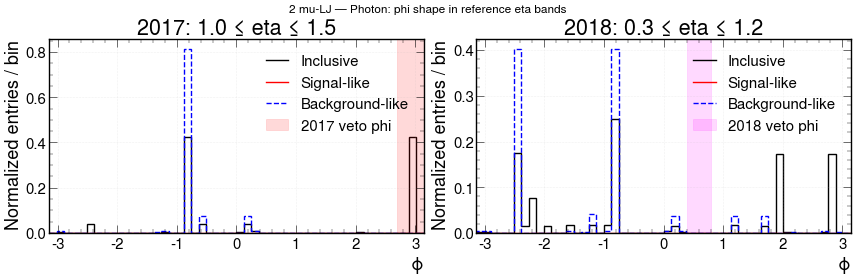

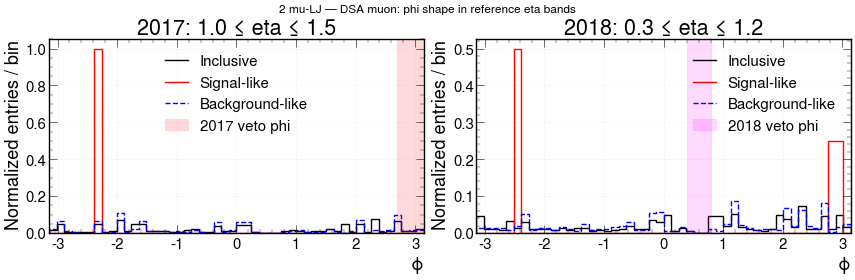

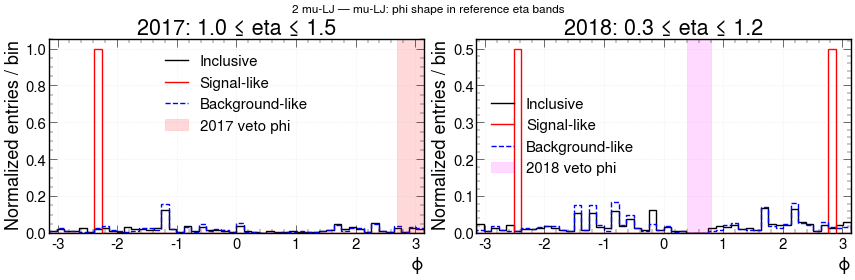

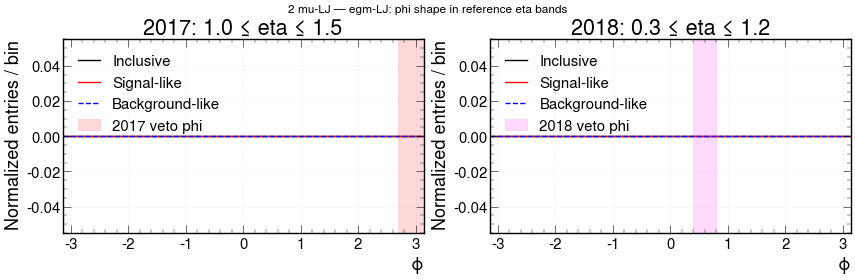

In [21]:
REGION_STYLES = {"Inclusive": ("black", "-"), "Signal-like": ("red", "-"), "Background-like": ("blue", "--")}
def phi_projection(histogram, eta_range):
    eta_edges, phi_edges, values, _ = eta_phi_arrays(histogram)
    eta = 0.5 * (eta_edges[:-1] + eta_edges[1:])
    selected = (eta >= eta_range[0]) & (eta <= eta_range[1])
    projection = values[selected, :].sum(axis=0)
    total = projection.sum()
    return phi_edges, projection / total if total > 0 else np.zeros_like(projection)

for channel_label in BASE_CHANNELS:
    for object_label, histogram_name in ETA_PHI_HISTOGRAMS.items():
        fig, axes = plt.subplots(1, 2, figsize=(17, 5.5), constrained_layout=True)
        for ax, (year, spec) in zip(axes, VETO_REGIONS.items()):
            for region, (color, linestyle) in REGION_STYLES.items():
                h = sum_eta_phi_histogram(SAMPLES, channel_name(channel_label, region), histogram_name)
                edges, shape = phi_projection(h, spec["eta"])
                ax.stairs(shape, edges, color=color, linestyle=linestyle, linewidth=2, label=region)
            ax.axvspan(*spec["phi"], color=spec["color"], alpha=0.15, label=f"{year} veto phi")
            ax.set(title=f"{year}: {spec['eta'][0]} ≤ eta ≤ {spec['eta'][1]}", xlabel=r"$\phi$", ylabel="Normalized entries / bin", xlim=(-np.pi, np.pi))
            ax.grid(linestyle=":", alpha=0.35); ax.legend(frameon=False)
        fig.suptitle(f"{channel_label} — {object_label}: phi shape in reference eta bands", fontsize=17)
        plt.show(); plt.close(fig)

In [22]:
process_rows = []
for channel_label in BASE_CHANNELS:
    channel = channel_name(channel_label, "Signal-like")
    for object_label, histogram_name in ETA_PHI_HISTOGRAMS.items():
        for process, samples in BACKGROUND_GROUPS.items():
            h = sum_eta_phi_histogram(samples, channel, histogram_name)
            for year, spec in VETO_REGIONS.items():
                selected, error, total, fraction = region_stats(h, spec)
                process_rows.append({"channel": channel_label, "object": object_label,
                                     "process": process, "reference": year,
                                     "region fraction": fraction, "region yield": selected})
process_occupancy = pd.DataFrame(process_rows)
display((100 * process_occupancy.pivot_table(index=["channel", "object"], columns=["reference", "process"], values="region fraction")).round(3))

reference                     2017                         2018          \
process                         DY Diboson    QCD     TT     DY Diboson   
channel            object                                                 
1 egm-LJ           DSA muon  0.000     NaN  0.001  0.000  0.000     NaN   
                   Electron  0.000     0.0  0.000  2.381  0.000     0.0   
                   Muon      0.955     0.0  0.635  1.042  0.060     0.0   
                   Photon    1.144     0.0  0.014  0.000  0.114     0.0   
                   egm-LJ    1.120     0.0  0.014  1.010  0.112     0.0   
1 mu-LJ            DSA muon  1.639     0.0  0.791  0.000  0.364     0.0   
                   Electron  0.000     0.0  0.003  0.000  0.000     0.0   
                   Muon      2.000     0.0  1.768  0.000  0.067     0.0   
                   Photon    0.000     NaN  7.345  0.000  0.000     NaN   
                   mu-LJ     2.590     0.0  2.357  0.000  0.137     0.0   
1 mu-LJ + 1 egm-LJ DSA muon    NaN     NaN  0.000  0.000    NaN     NaN   
                   Electron    NaN     NaN  0.000    NaN    NaN     NaN   
                   Muon        NaN     NaN  0.000  0.000    NaN     NaN   
                   Photon      NaN     NaN  0.099  0.000    NaN     NaN   
                   egm-LJ      NaN     NaN  0.053  0.000    NaN     NaN   
                   mu-LJ       NaN     NaN  0.000  0.000    NaN     NaN   
2 mu-LJ            DSA muon  0.000     NaN  0.000  0.000  0.000     NaN   
                   Electron    NaN     NaN  0.000    NaN    NaN     NaN   
                   Muon      0.000     NaN  0.000  0.000  0.000     NaN   
                   mu-LJ     0.000     NaN  0.000  0.000  0.000     NaN   

reference                                  
process                        QCD     TT  
channel            object                  
1 egm-LJ           DSA muon  0.000  0.000  
                   Electron  0.000  0.000  
                   Muon      0.000  0.000  
                   Photon    0.006  0.000  
                   egm-LJ    0.006  0.000  
1 mu-LJ            DSA muon  0.250  5.263  
                   Electron  0.000  0.000  
                   Muon      0.127  1.316  
                   Photon    0.040  0.000  
                   mu-LJ     0.141  3.030  
1 mu-LJ + 1 egm-LJ DSA muon  0.000  0.000  
                   Electron  0.000    NaN  
                   Muon      0.000  0.000  
                   Photon    0.000  0.000  
                   egm-LJ    0.000  0.000  
                   mu-LJ     0.000  0.000  
2 mu-LJ            DSA muon  0.000  0.000  
                   Electron  0.000    NaN  
                   Muon      0.000  0.000  
                   mu-LJ     0.000  0.000

## Interpretation checklist

Evidence supporting the pixel-hotspot hypothesis would be: (1) a localized excess overlapping a reference rectangle, (2) increased rectangle occupancy in Signal-like relative to inclusive/background-like selections, and (3) the feature appearing across more than one background process. Absence from prompt muons but presence in electrons/egm-LJs would also resemble the reference observation.

A veto should **not** be adopted from these plots alone. Confirm the feature in collision data split by year/run, inspect missing-inner-hit or valid-pixel-hit variables for objects inside and outside the rectangle, and quantify signal efficiency plus background rejection before changing the selection.

# Final summary

The tables below place the principal 1-LJ/2-LJ yield fractions and eta–phi reference-region fractions together for final review. Interpretation should use both normalization and shape information; a detector veto should not be inferred from MC geometry alone.

In [23]:
display(Markdown("## LJ-entry selection fractions"))
display(lj_yield_summary.round(5))
display(Markdown("## Eta-phi reference-region fractions (%)"))
display((100 * fraction_table).round(3))
display(Markdown("## Signal-like process-resolved reference-region fractions (%)"))
display((100 * process_occupancy.pivot_table(
    index=["channel", "object"],
    columns=["reference", "process"],
    values="region fraction",
)).round(3))

## LJ-entry selection fractions

inclusive_lj_entry_yield  signal_like_fraction  \
channel            process                                                   
1 mu-LJ            Diboson              4.941822e+02               0.01747   
                   TT                   1.846669e+04               0.00585   
                   DY                   8.034449e+04               0.02955   
                   QCD                  9.332675e+06               0.01019   
1 egm-LJ           Diboson              5.376240e+01               0.26322   
                   TT                   3.463527e+03               0.09357   
                   DY                   4.438157e+03               0.65335   
                   QCD                  3.334619e+04               0.34594   
1 mu-LJ + 1 egm-LJ Diboson              1.776375e+01               0.00000   
                   TT                   2.717133e+03               0.00120   
                   DY                   9.743920e+02               0.00000   
                   QCD                  7.097139e+04               0.00257   
2 mu-LJ            Diboson              7.261390e+00               0.00000   
                   TT                   4.583117e+02               0.01429   
                   DY                   9.920934e+02               0.00655   
                   QCD                  4.988947e+04               0.00000   

                            background_like_fraction  
channel            process                            
1 mu-LJ            Diboson                   0.17329  
                   TT                        0.69278  
                   DY                        0.05185  
                   QCD                       0.68721  
1 egm-LJ           Diboson                   0.10907  
                   TT                        0.22779  
                   DY                        0.10573  
                   QCD                       0.38390  
1 mu-LJ + 1 egm-LJ Diboson                   0.00000  
                   TT                        0.16024  
                   DY                        0.01333  
                   QCD                       0.36428  
2 mu-LJ            Diboson                   0.05693  
                   TT                        0.50000  
                   DY                        0.00000  
                   QCD                       0.67397

## Eta-phi reference-region fractions (%)

reference                              2017                        \
selection                   Background-like Inclusive Signal-like   
channel            object                                           
1 egm-LJ           DSA muon           1.915     0.825       0.001   
                   Electron           0.261     0.390       0.156   
                   Muon               0.561     0.820       0.730   
                   Photon             0.160     0.340       0.236   
                   egm-LJ             0.263     0.361       0.253   
1 mu-LJ            DSA muon           1.044     0.823       0.816   
                   Electron           1.309     1.118       0.003   
                   Muon               1.026     1.020       1.772   
                   Photon             1.447     2.023       7.163   
                   mu-LJ              1.031     1.007       2.360   
1 mu-LJ + 1 egm-LJ DSA muon           0.293     0.223       0.000   
                   Electron           3.152     2.226       0.000   
                   Muon               0.692     0.711       0.000   
                   Photon             1.392     0.810       0.095   
                   egm-LJ             3.211     1.770       0.052   
                   mu-LJ              0.834     0.656       0.000   
2 mu-LJ            DSA muon           2.391     1.758       0.000   
                   Electron           0.087     0.178       0.000   
                   Muon               0.993     0.785       0.000   
                   Photon             0.000     0.833         NaN   
                   mu-LJ              1.153     0.883       0.000   

reference                              2018                        \
selection                   Background-like Inclusive Signal-like   
channel            object                                           
1 egm-LJ           DSA muon           0.002     0.001       0.000   
                   Electron           0.015     0.038       0.000   
                   Muon               0.039     0.035       0.016   
                   Photon             0.000     0.019       0.027   
                   egm-LJ             0.010     0.029       0.026   
1 mu-LJ            DSA muon           0.238     0.202       0.259   
                   Electron           0.020     0.015       0.000   
                   Muon               0.046     0.071       0.127   
                   Photon             0.281     0.123       0.039   
                   mu-LJ              0.034     0.046       0.144   
1 mu-LJ + 1 egm-LJ DSA muon           0.023     0.090       0.000   
                   Electron           0.015     0.016       0.000   
                   Muon               0.003     0.007       0.000   
                   Photon             0.000     0.081       0.000   
                   egm-LJ             0.016     0.043       0.000   
                   mu-LJ              0.000     0.011       0.000   
2 mu-LJ            DSA muon           0.116     0.130       0.000   
                   Electron           0.033     0.018       0.000   
                   Muon               0.030     0.021       0.000   
                   Photon             0.000     0.000         NaN   
                   mu-LJ              0.028     0.020       0.000   

reference                               2017             2018  
selection                   pass / inclusive pass / inclusive  
channel            object                                      
1 egm-LJ           DSA muon            0.075            0.000  
                   Electron           39.920            0.000  
                   Muon               89.032           45.907  
                   Photon             69.548          146.223  
                   egm-LJ             70.084           91.447  
1 mu-LJ            DSA muon           99.127          127.722  
                   Electron            0.225            0.000  
                   Muon              173.735  

## Signal-like process-resolved reference-region fractions (%)

reference                     2017                         2018          \
process                         DY Diboson    QCD     TT     DY Diboson   
channel            object                                                 
1 egm-LJ           DSA muon  0.000     NaN  0.001  0.000  0.000     NaN   
                   Electron  0.000     0.0  0.000  2.381  0.000     0.0   
                   Muon      0.955     0.0  0.635  1.042  0.060     0.0   
                   Photon    1.144     0.0  0.014  0.000  0.114     0.0   
                   egm-LJ    1.120     0.0  0.014  1.010  0.112     0.0   
1 mu-LJ            DSA muon  1.639     0.0  0.791  0.000  0.364     0.0   
                   Electron  0.000     0.0  0.003  0.000  0.000     0.0   
                   Muon      2.000     0.0  1.768  0.000  0.067     0.0   
                   Photon    0.000     NaN  7.345  0.000  0.000     NaN   
                   mu-LJ     2.590     0.0  2.357  0.000  0.137     0.0   
1 mu-LJ + 1 egm-LJ DSA muon    NaN     NaN  0.000  0.000    NaN     NaN   
                   Electron    NaN     NaN  0.000    NaN    NaN     NaN   
                   Muon        NaN     NaN  0.000  0.000    NaN     NaN   
                   Photon      NaN     NaN  0.099  0.000    NaN     NaN   
                   egm-LJ      NaN     NaN  0.053  0.000    NaN     NaN   
                   mu-LJ       NaN     NaN  0.000  0.000    NaN     NaN   
2 mu-LJ            DSA muon  0.000     NaN  0.000  0.000  0.000     NaN   
                   Electron    NaN     NaN  0.000    NaN    NaN     NaN   
                   Muon      0.000     NaN  0.000  0.000  0.000     NaN   
                   mu-LJ     0.000     NaN  0.000  0.000  0.000     NaN   

reference                                  
process                        QCD     TT  
channel            object                  
1 egm-LJ           DSA muon  0.000  0.000  
                   Electron  0.000  0.000  
                   Muon      0.000  0.000  
                   Photon    0.006  0.000  
                   egm-LJ    0.006  0.000  
1 mu-LJ            DSA muon  0.250  5.263  
                   Electron  0.000  0.000  
                   Muon      0.127  1.316  
                   Photon    0.040  0.000  
                   mu-LJ     0.141  3.030  
1 mu-LJ + 1 egm-LJ DSA muon  0.000  0.000  
                   Electron  0.000    NaN  
                   Muon      0.000  0.000  
                   Photon    0.000  0.000  
                   egm-LJ    0.000  0.000  
                   mu-LJ     0.000  0.000  
2 mu-LJ            DSA muon  0.000  0.000  
                   Electron  0.000    NaN  
                   Muon      0.000  0.000  
                   mu-LJ     0.000  0.000